# LSTM Analysis SLE Labor Force Exit

## Functions

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import cross_val_predict
import random
import matplotlib.pyplot as plt


In [23]:
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



In [24]:
def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Generate dynamic risk predictions for a patient across visits"""
    X_patient = np.zeros((1, max_seq_length, len(features)))
    seq_len = len(patient_data)
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get cumulative predictions at each time point
    risks = []
    for t in range(1, seq_len + 1):
        pred = model.predict(X_patient[:, :t, :], verbose=0)
        exit_risk = pred[0][1]  # Assuming class 1 is labor force exit
        risks.append(exit_risk)
    
    return pd.DataFrame({
        'ASSDT': patient_data['ASSDT'].values,
        'Risk_Score': risks,
        'SLEDAI': patient_data['SLEDAI2_I'].values,
        'Steroid_Dose': patient_data['STERDOSE'].values,
        'SDI': patient_data['score_n'].values,  # Added SDI
        'Immunosuppressant': patient_data['ISDOSE'].values,  # Added IMDOSE
        'Employment_Status': patient_data['EMPf'].values
    })


In [25]:

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

In [26]:

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

In [27]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure with larger width to accommodate multiple axes
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0, 1)  # Force risk score axis to start at 0 and end at 1
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Define colors and styles for each clinical marker
    clinical_markers = {
        'SLEDAI': ('g', '--'),
        'Steroid (mg)': ('m', ':'),
        'SDI': ('c', '-'),
        'Immunosuppressant (mg)': ('y', '-.')
    }
    
    # Create right axes for each clinical marker
    axes_right = {}
    offset = 60  # Pixel offset for each additional axis
    
    for i, (marker_name, (color, linestyle)) in enumerate(clinical_markers.items()):
        # Create new axis, offset from the previous one
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset * i))
        
        # Plot the clinical marker
        ax.plot(risk_df['Age'], risk_df[f'{marker_name.split(" ")[0]}_unscaled'], 
               color=color, linestyle=linestyle, label=marker_name)
        
        # Style the axis and set y-lim to start at 0
        ax.set_ylabel(marker_name, color=color, fontsize=12)
        ax.tick_params(axis='y', labelcolor=color)
        
        # Get the max value for this marker to set upper bound
        max_val = risk_df[f'{marker_name.split(" ")[0]}_unscaled'].max()
        buffer = max_val * 0.25  # Add 10% buffer above max value
        ax.set_ylim(0, max_val + buffer)
        
        # Store the axis for later reference
        axes_right[marker_name] = ax
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for ax in axes_right.values():
        lines, labels = ax.get_legend_handles_labels()
        lines_right.extend(lines)
        labels_right.extend(labels)
    
    ax1.legend(lines1 + lines_right, labels1 + labels_right, loc='upper left')
    
    plt.tight_layout()
    plt.show()

## Train Model

In [33]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/3580384684.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/3580384684.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Find High Patients

In [39]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2470185762.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2470185762.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.2441 - loss: 1.7391 - val_accuracy: 0.0829 - val_loss: 1.7935
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.1191 - loss: 1.8349 - val_accuracy: 0.3171 - val_loss: 1.7846
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.3360 - loss: 1.5972 - val_accuracy: 0.5220 - val_loss: 1.7322
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.5794 - loss: 1.5108 - val_accuracy: 0.7122 - val_loss: 1.6597
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.7104 - loss: 1.6045 - val_accuracy: 0.7659 - val_loss: 1.4035
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.7677 - loss: 1.5788 - val_accuracy: 0.7610 - val_loss: 1.3655
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.7798 - loss: 1.4596 - val_accuracy: 0.7463 - val_loss: 1.1996
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.7892 - loss: 1.3461 - val_accuracy: 0

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


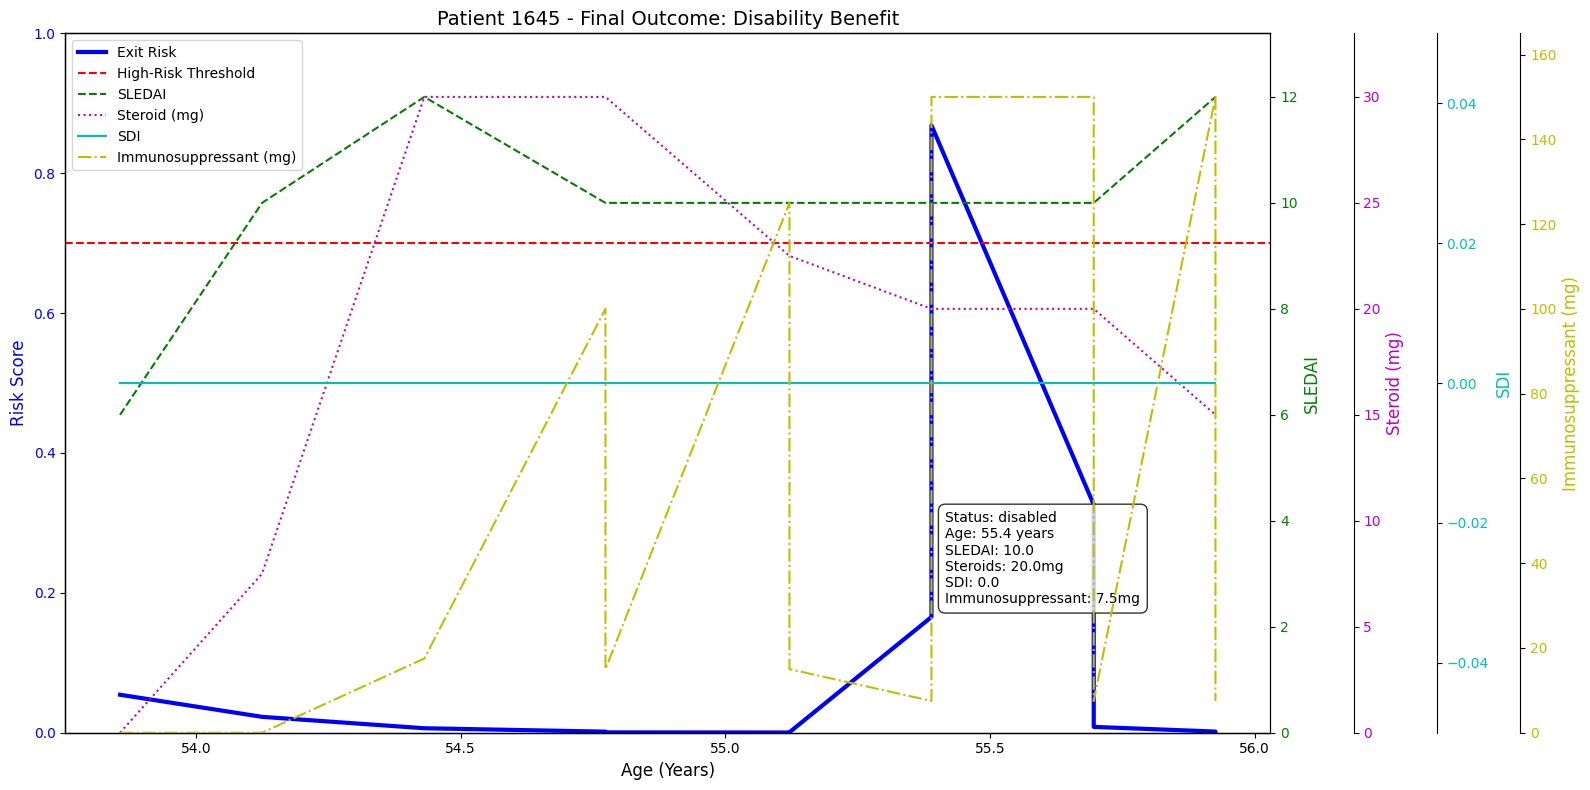

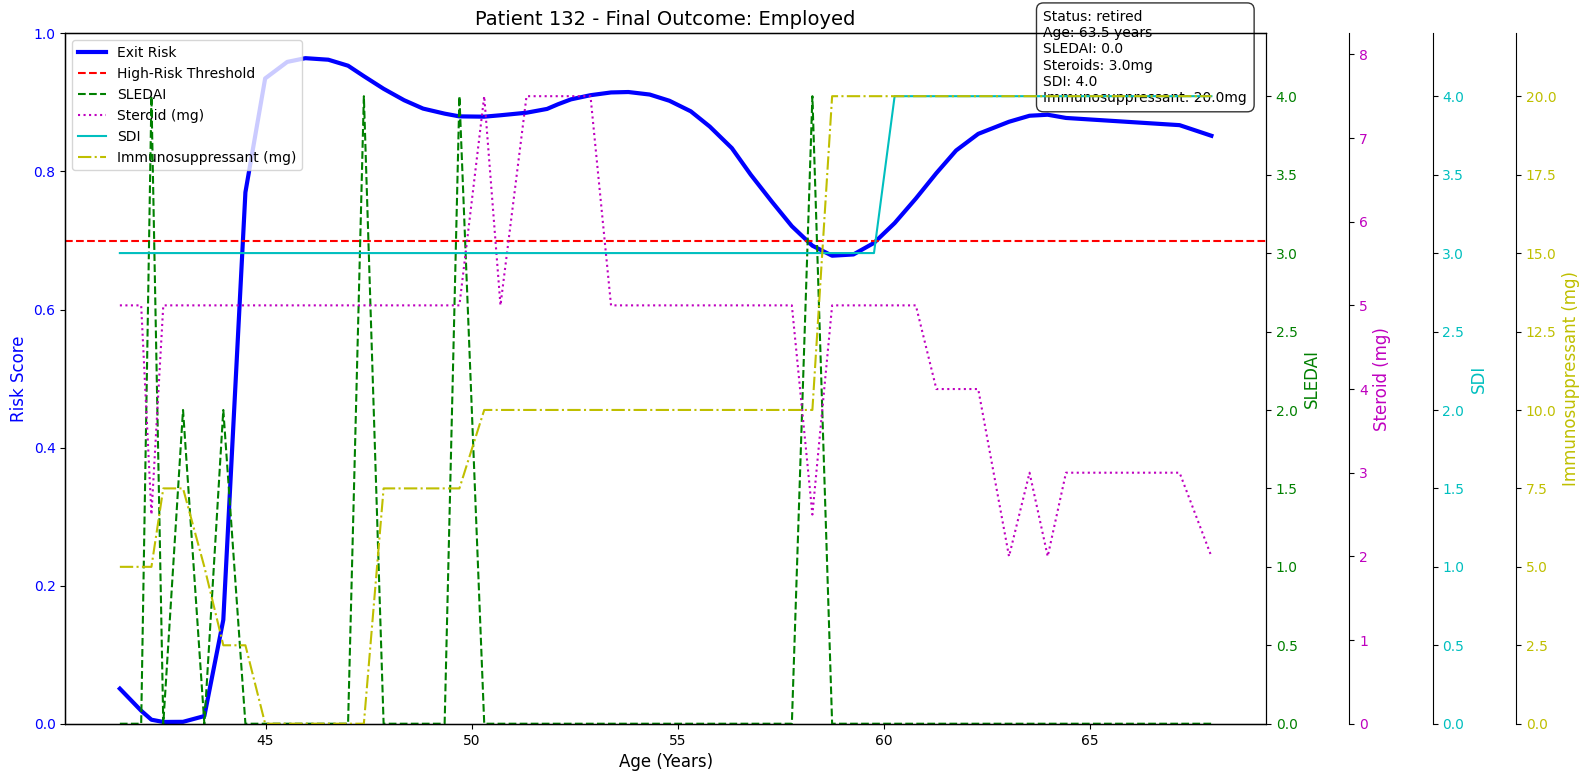

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


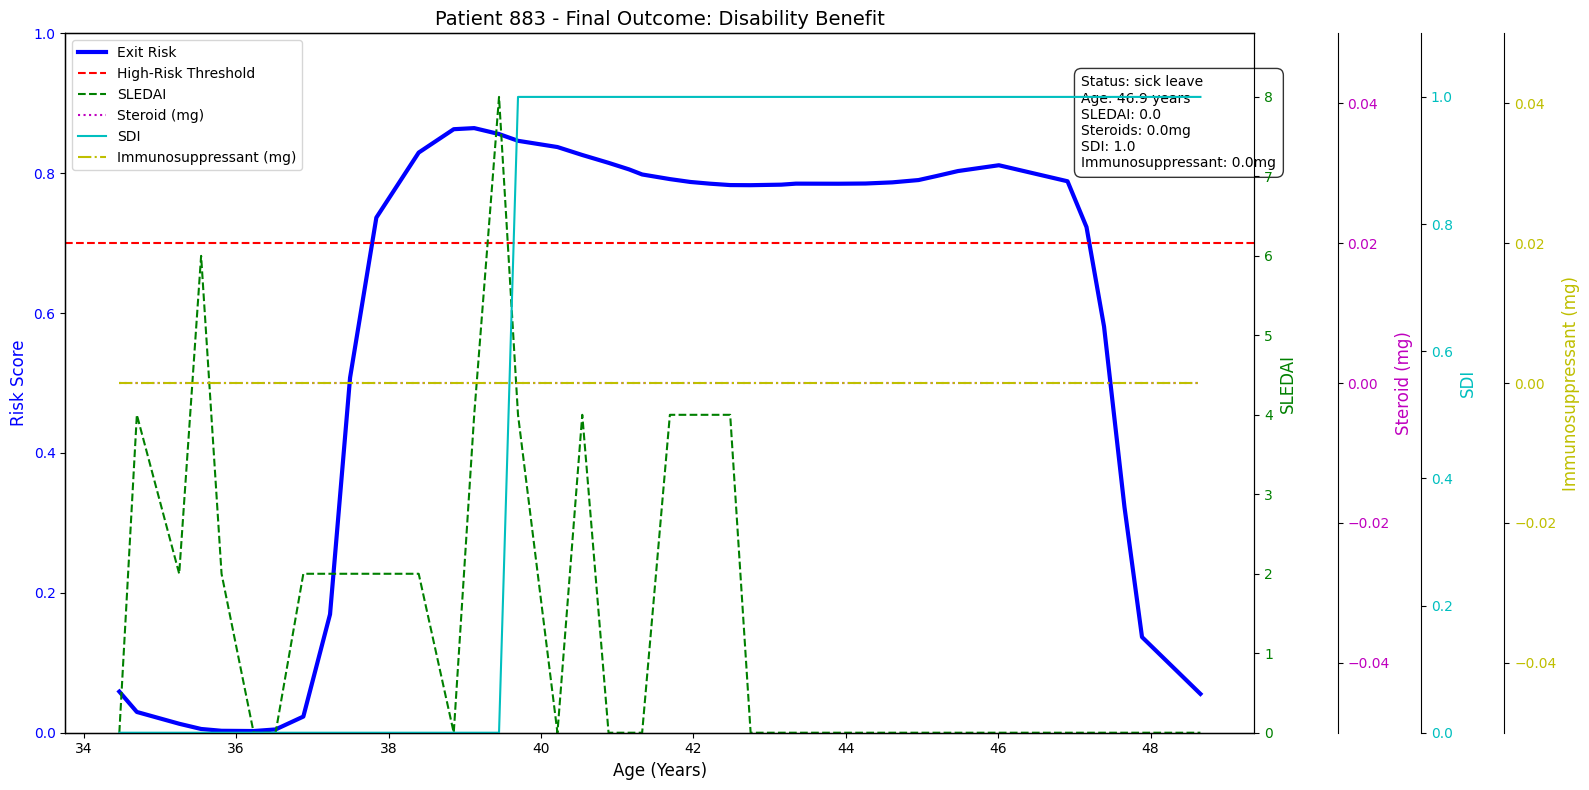

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


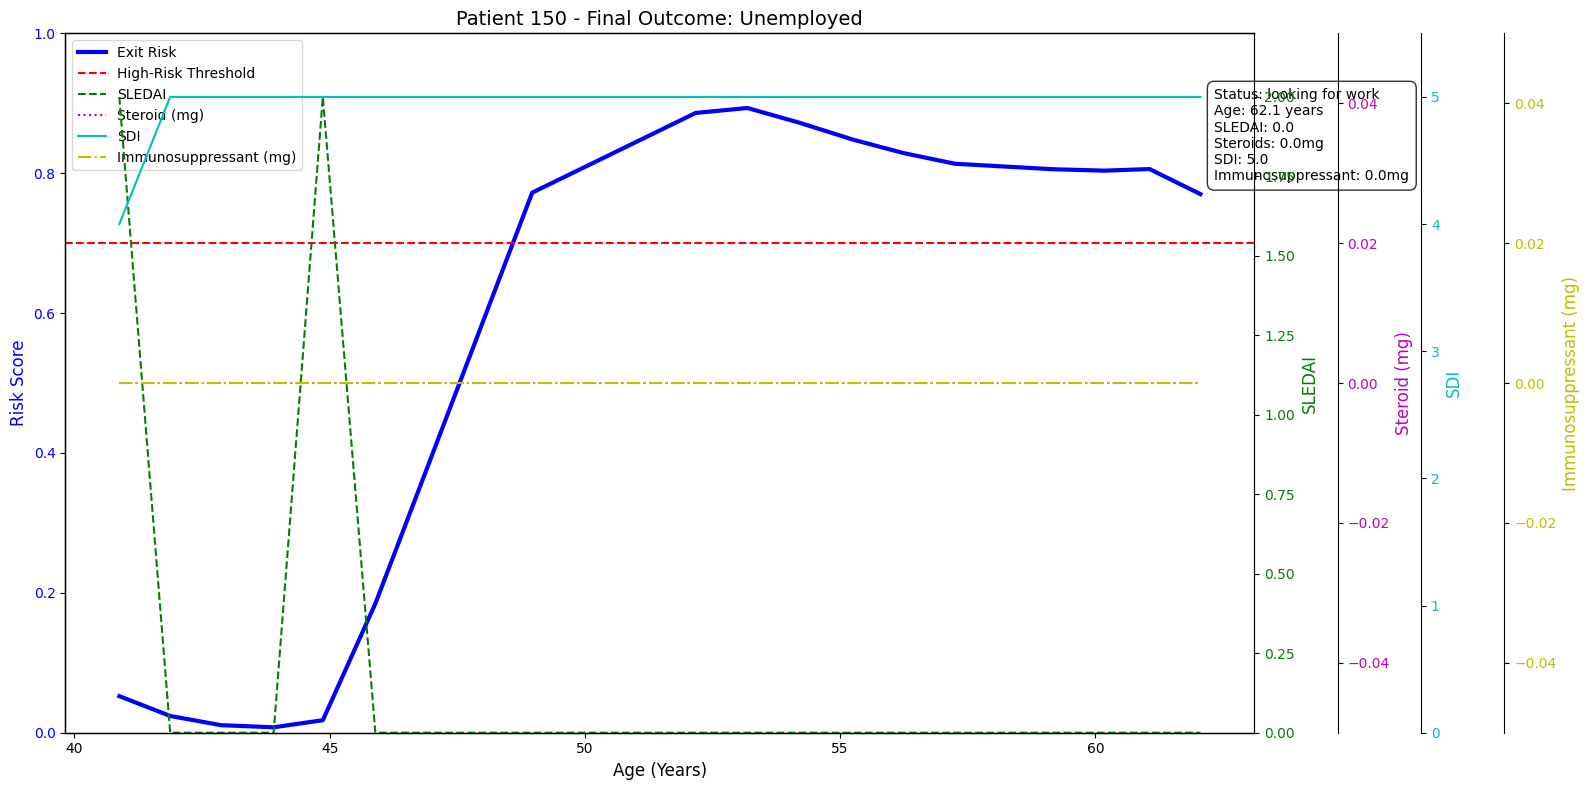

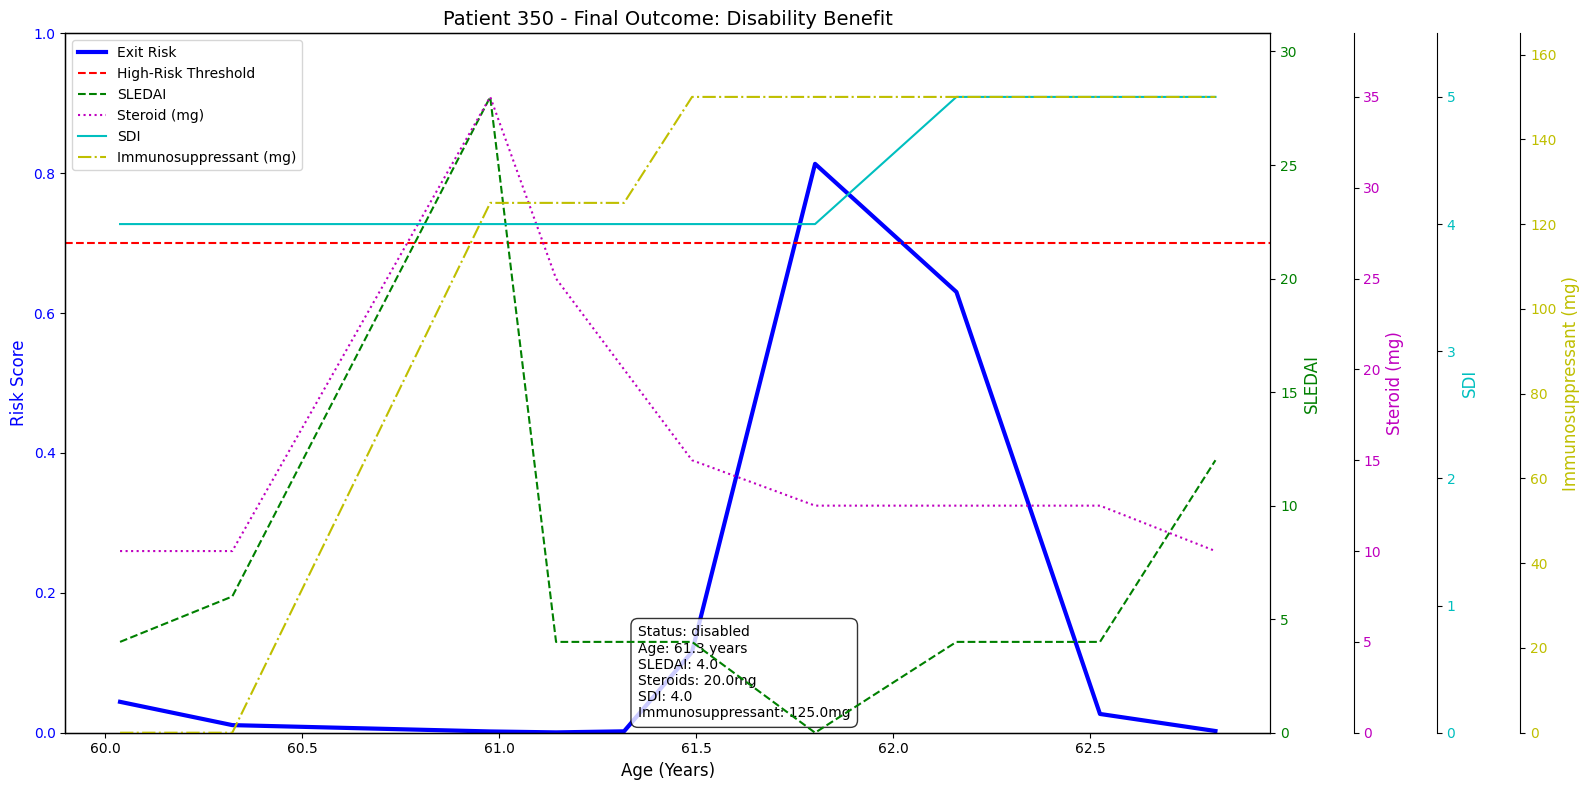

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


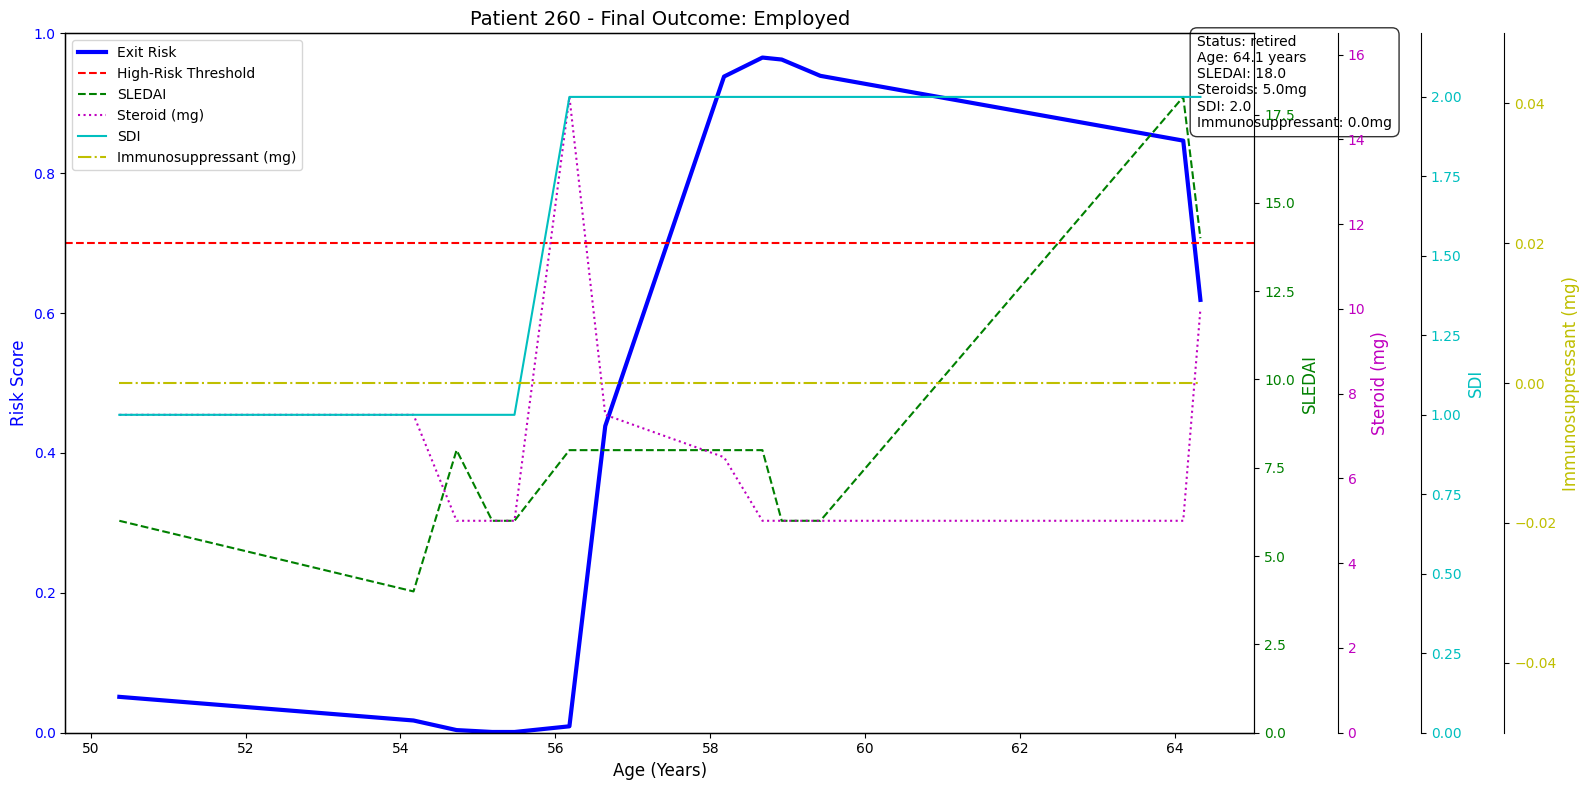

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


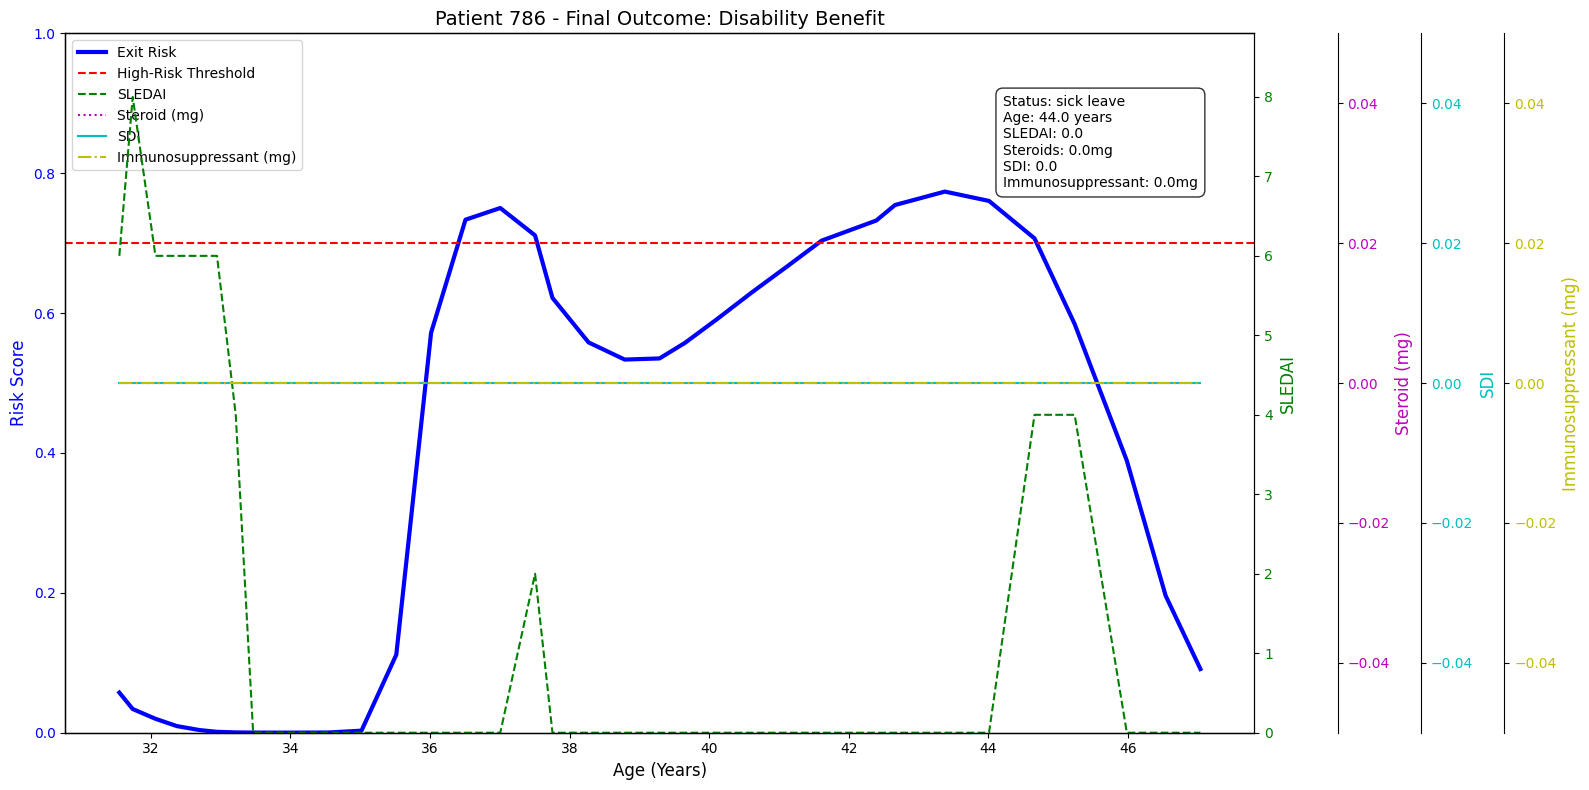

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


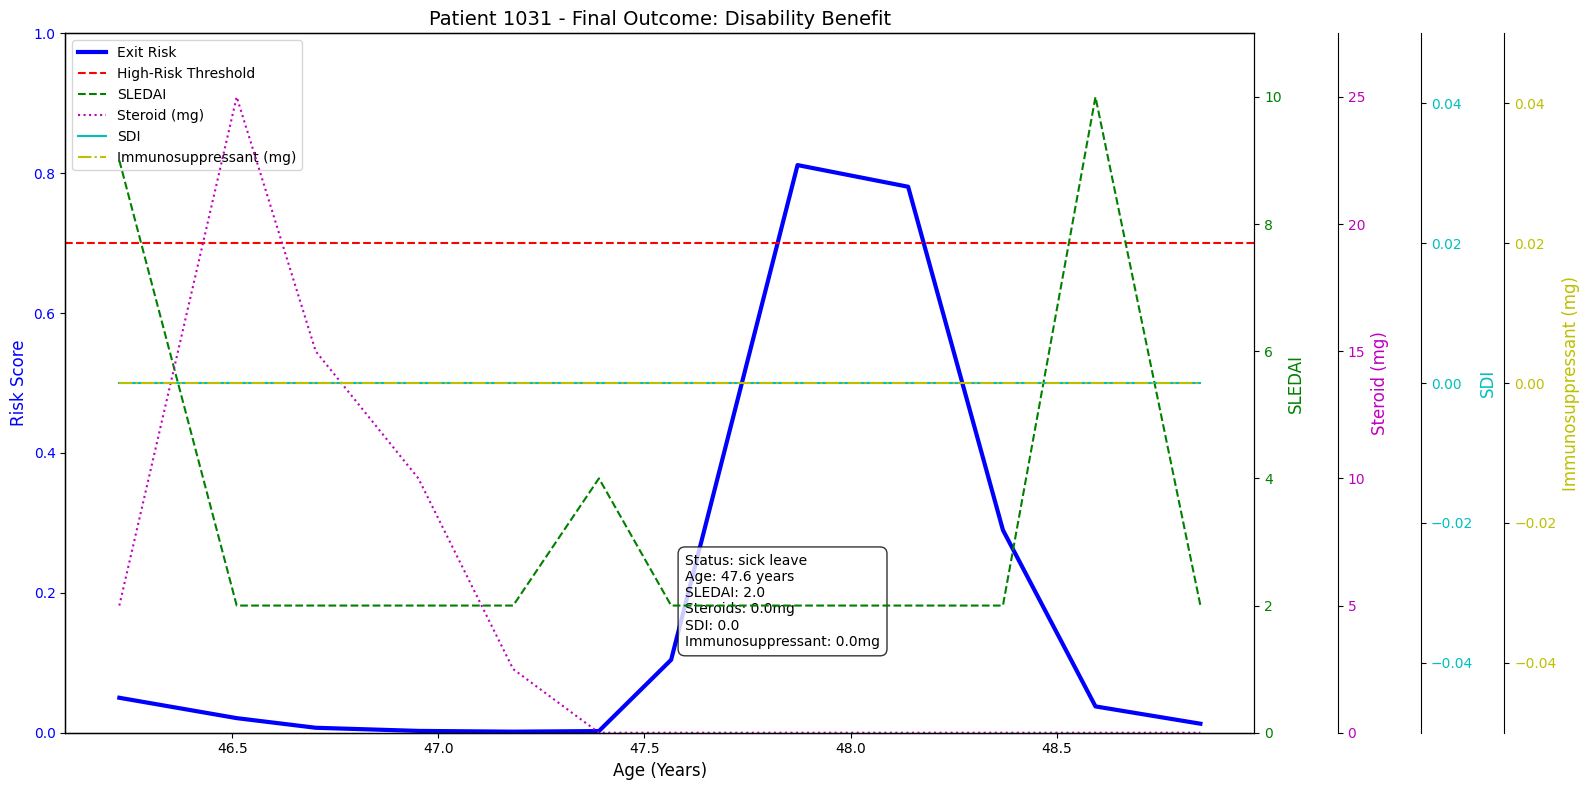

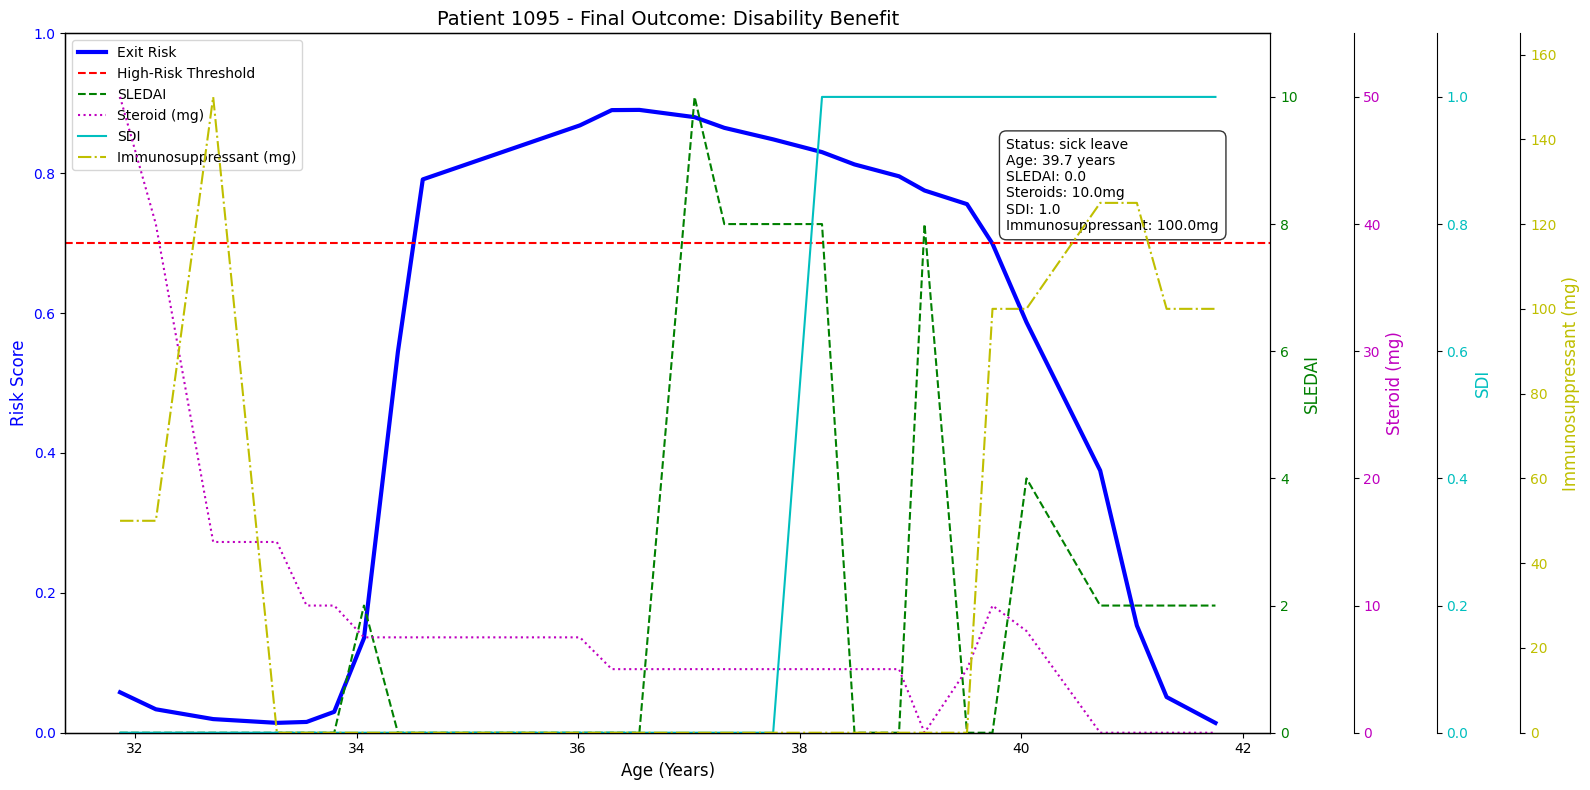

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2331368619.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


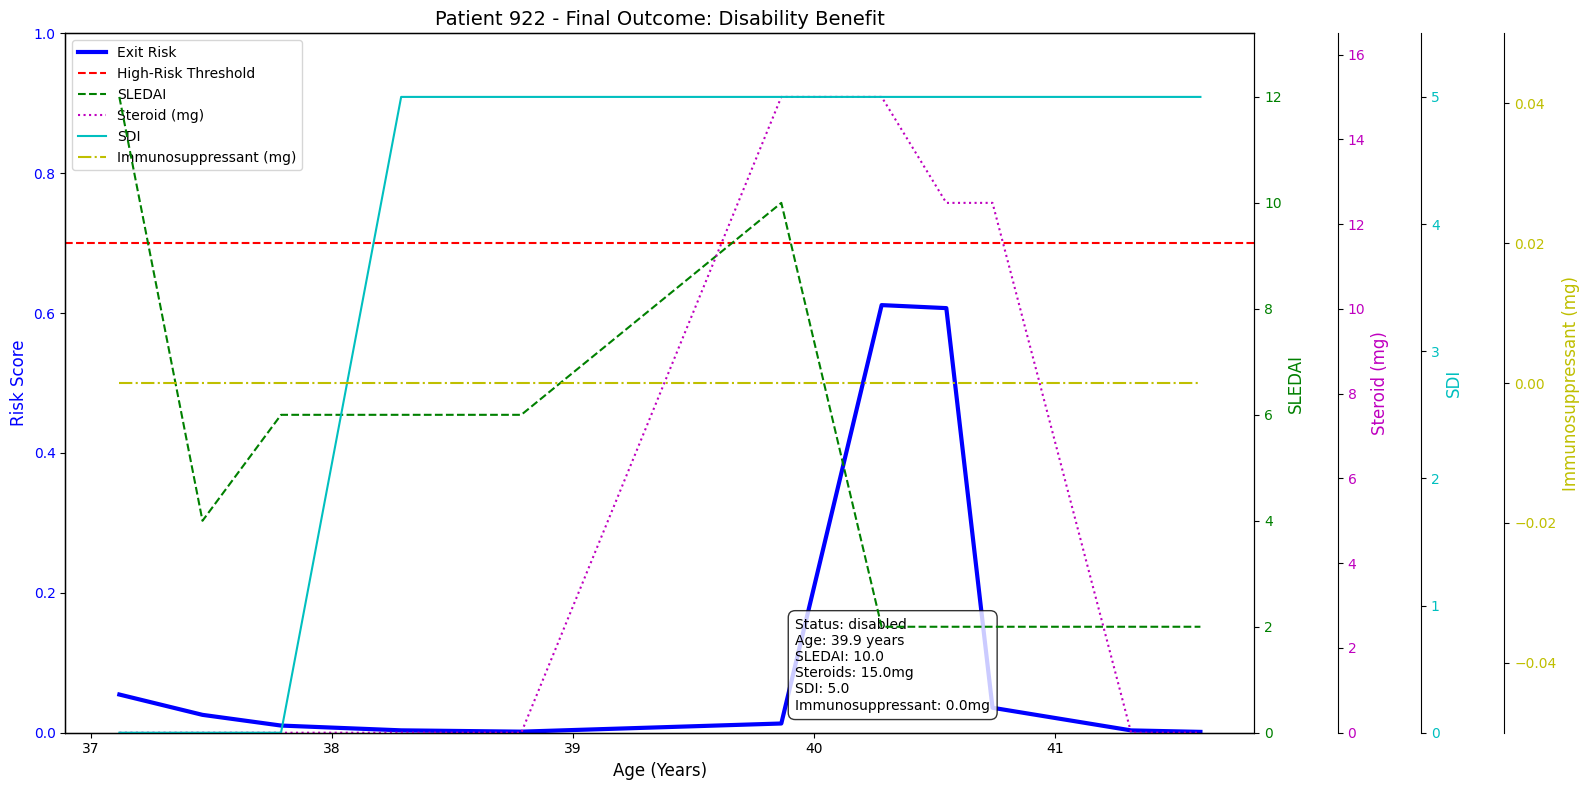

In [40]:
### Train Test Split
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure with larger width to accommodate multiple axes
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0, 1)  # Force risk score axis to start at 0 and end at 1
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Define colors and styles for each clinical marker
    clinical_markers = {
        'SLEDAI': ('g', '--'),
        'Steroid (mg)': ('m', ':'),
        'SDI': ('c', '-'),
        'Immunosuppressant (mg)': ('y', '-.')
    }
    
    # Create right axes for each clinical marker
    axes_right = {}
    offset = 60  # Pixel offset for each additional axis
    
    for i, (marker_name, (color, linestyle)) in enumerate(clinical_markers.items()):
        # Create new axis, offset from the previous one
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset * i))
        
        # Plot the clinical marker
        ax.plot(risk_df['Age'], risk_df[f'{marker_name.split(" ")[0]}_unscaled'], 
               color=color, linestyle=linestyle, label=marker_name)
        
        # Style the axis and set y-lim to start at 0
        ax.set_ylabel(marker_name, color=color, fontsize=12)
        ax.tick_params(axis='y', labelcolor=color)
        
        # Get the max value for this marker to set upper bound
        max_val = risk_df[f'{marker_name.split(" ")[0]}_unscaled'].max()
        buffer = max_val * 0.1  # Add 10% buffer above max value
        ax.set_ylim(0, max_val + buffer)
        
        # Store the axis for later reference
        axes_right[marker_name] = ax
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for ax in axes_right.values():
        lines, labels = ax.get_legend_handles_labels()
        lines_right.extend(lines)
        labels_right.extend(labels)
    
    ax1.legend(lines1 + lines_right, labels1 + labels_right, loc='upper left')
    
    plt.tight_layout()
    plt.show()

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
high_risk_df = get_high_risk_patients(model, data, features)


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)


## Visualize trajectories

In [ ]:

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)


In [48]:
# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flares', 'mild_flares', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n']  # Added score_n (SDI)

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flares', 'mild_flares']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with flare-based criteria including SDI"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules based on flares, steroids, and SDI
    THRESHOLD_RULES = [
        {'conditions': {
            'severe_flares': lambda x: x >= 1,  # At least 1 severe flare
            'STEROID_CAT': lambda x: x in ['Medium', 'High'],
            'score_n': lambda x: x >= 1},  # SDI ≥ 1
         'risk_threshold': 0.35},
        {'conditions': {
            'severe_flares': lambda x: x >= 1,
            'STEROID_CAT': lambda x: x in ['Medium', 'High']},
         'risk_threshold': 0.4},
        {'conditions': {
            'mild_flares': lambda x: x >= 2,  # 2+ mild flares
            'score_n': lambda x: x >= 1},  # With SDI ≥ 1
         'risk_threshold': 0.3},
        {'conditions': {
            'score_n': lambda x: x >= 2},  # High SDI (≥2) alone
         'risk_threshold': 0.4},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'Severe_Flares_at_Warning': best_warning['context']['severe_flares'],
                    'Mild_Flares_at_Warning': best_warning['context']['mild_flares'],
                    'SDI_at_Warning': best_warning['context']['score_n'],  # Added SDI
                    'Steroid_Category_at_Warning': best_warning['context']['STEROID_CAT'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report focusing on flares, steroid use, and SDI"""
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'Severe_Flares_at_Warning': 'severe_flares',
        'Mild_Flares_at_Warning': 'mild_flares',
        'SDI_at_Warning': 'score_n',  # SDI
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['Severe_Flares_unscaled'] = unscaled_array[:, feature_pos.get('severe_flares', 0)]
    high_risk_df['Mild_Flares_unscaled'] = unscaled_array[:, feature_pos.get('mild_flares', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]  # SDI
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with flare, steroid, and SDI focus
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Flare_Patterns': {
            'Any_Severe_Flare': f"{len(high_risk_df[high_risk_df['Severe_Flares_unscaled'] >= 1])/len(high_risk_df):.0%} had ≥1 severe flare",
            'Persistent_Mild_Flares': f"{len(high_risk_df[high_risk_df['Mild_Flares_unscaled'] >= 2])/len(high_risk_df):.0%} had ≥2 mild flares"
        },
        'Damage_Index': {
            'Any_Damage': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Significant_Damage': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 2])/len(high_risk_df):.0%} had SDI ≥2",
            'Damage_with_Flares': f"{len(high_risk_df[(high_risk_df['SDI_unscaled'] >= 1) & 
                                                     (high_risk_df['Severe_Flares_unscaled'] >= 1)])/len(high_risk_df):.0%} had damage+severe flares"
        },
        'Steroid_Use': {
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_Category_at_Warning'] == 'High'])/len(high_risk_df):.0%} on high steroids",
            'Medium_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_Category_at_Warning'] == 'Medium'])/len(high_risk_df):.0%} on medium steroids",
            'Steroids_with_Damage': f"{len(high_risk_df[(high_risk_df['Steroid_Category_at_Warning'] != 'Low') & 
                                                       (high_risk_df['SDI_unscaled'] >= 1)])/len(high_risk_df):.0%} had steroids+damage"
        },
        'Median_Values': {
            'Severe_Flares': high_risk_df['Severe_Flares_unscaled'].median(),
            'Mild_Flares': high_risk_df['Mild_Flares_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        }
    }
    
    return report, high_risk_df

# Execute the analysis
high_risk_df = get_high_risk_patients(model, data, features)
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print results
print("\n=== Clinical Insights (Flares, Steroids, and SDI) ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")

print("\nFlare Patterns in High-Risk Patients:")
for k, v in clinical_report['Flare_Patterns'].items():
    print(f"- {v}")

print("\nDisease Damage (SDI) in High-Risk Patients:")
for k, v in clinical_report['Damage_Index'].items():
    print(f"- {v}")

print("\nSteroid Use in High-Risk Patients:")
for k, v in clinical_report['Steroid_Use'].items():
    print(f"- {v}")

print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.1f}")

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2543995774.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2543995774.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])


Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.0831 - loss: 1.7021 - val_accuracy: 0.1268 - val_loss: 1.8169
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.1353 - loss: 1.6318 - val_accuracy: 0.1610 - val_loss: 1.8243
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.1806 - loss: 1.7425 - val_accuracy: 0.1951 - val_loss: 1.8025
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.2548 - loss: 1.4953 - val_accuracy: 0.2634 - val_loss: 1.7650
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.2615 - loss: 1.5878 - val_accuracy: 0.6829 - val_loss: 1.6994
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.5872 - loss: 1.5737 - val_accuracy: 0.5756 - val_loss: 1.6829
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.4828 - loss: 1.6097 - val_accuracy: 0.6000 - val_loss: 1.6501
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.5120 - loss: 1.3505 - val_accuracy: 0.6780 - val_

KeyboardInterrupt: 

In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flares', 'mild_flares', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n']  # Added score_n (SDI)

# Add total flares feature
data['total_flares'] = data['severe_flares'] + data['mild_flares']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flares']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']

# Add temporal features
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1)  # +1 to avoid division by zero

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO').apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
).reset_index(level=0, drop=True)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 
             'flares_per_month', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flares', 'mild_flares']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test, seq_lengths_train, seq_lengths_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1))

# Build enhanced LSTM model
num_classes = y.shape[1]



/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/1794009733.py:17: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/1794009733.py:18: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/1794009733.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PT

IndexError: tuple index out of range

In [67]:
from keras.utils import Sequence

class AugmentedSequenceGenerator(Sequence):
    def __init__(self, X, y, seq_lengths, batch_size=32, noise_factor=0.05):
        self.X = X
        self.y = y
        self.seq_lengths = seq_lengths
        self.batch_size = batch_size
        self.noise_factor = noise_factor
        self.indices = np.arange(len(X))
        self.on_epoch_end()
        
    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        X_batch = self.X[batch_indices].copy()
        y_batch = self.y[batch_indices]
        
        # Apply augmentation
        mask = (X_batch != 0)
        noise = self.noise_factor * np.random.normal(size=X_batch.shape)
        X_batch = X_batch + noise * mask
        
        return X_batch, y_batch
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

# Modified data augmentation function
def augment_sequences(X, y, seq_lengths, noise_factor=0.05):
    X_aug = X.copy()
    # Add small Gaussian noise only to non-zero entries
    mask = (X_aug != 0)
    noise = noise_factor * np.random.normal(size=X_aug.shape)
    X_aug = X_aug + noise * mask
    return X_aug, y, seq_lengths

# Prepare the training data without augmentation first to check shapes
X_train_aug, y_train_aug, seq_lengths_train_aug = augment_sequences(X_train, y_train, seq_lengths_train)

# Verify shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"seq_lengths_train shape: {seq_lengths_train.shape}")

# Train the model - first without augmentation to test
print("\nTraining without augmentation first to verify...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

# Now try with augmentation if the above works
print("\nTraining with augmentation...")

# Need to create a generator that applies augmentation on the fly
class AugmentedSequenceGenerator:
    def __init__(self, X, y, seq_lengths, batch_size=32, noise_factor=0.05):
        self.X = X
        self.y = y
        self.seq_lengths = seq_lengths
        self.batch_size = batch_size
        self.noise_factor = noise_factor
        self.indices = np.arange(len(X))
        np.random.shuffle(self.indices)
        self.current_index = 0
        
    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        X_batch = self.X[batch_indices].copy()
        y_batch = self.y[batch_indices]
        
        # Apply augmentation
        mask = (X_batch != 0)
        noise = self.noise_factor * np.random.normal(size=X_batch.shape)
        X_batch = X_batch + noise * mask
        
        return X_batch, y_batch
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)
        self.current_index = 0

import tensorflow as tf

def create_augmented_dataset(X, y, seq_lengths, batch_size=32, noise_factor=0.05):
    # Create a dataset from numpy arrays
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    # Define the augmentation function
    def augment(x, y):
        # Add noise only to non-zero elements
        mask = tf.cast(tf.not_equal(x, 0), tf.float64)  # Match input type
        noise = noise_factor * tf.random.normal(tf.shape(x), dtype=tf.float64)  # Use float64
        x_aug = x + noise * mask
        return x_aug, y
    
    # Apply augmentation, shuffle and batch
    dataset = dataset.map(augment)
    dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create the augmented dataset
train_dataset = create_augmented_dataset(
    X_train, 
    y_train, 
    seq_lengths_train,
    batch_size=32,
    noise_factor=0.05
)

# Train with the augmented dataset
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Make predictions
y_pred = model.predict(X_test)

# Ensemble with Random Forest
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X, seq_lengths, features)
y_labels = np.argmax(y, axis=1)

# Train RF on last observations
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced')
rf_pred = cross_val_predict(rf, X_last, y_labels, cv=5, method='predict_proba')

# Get RF predictions for test set
test_indices = [i for i in range(len(X)) if i in [np.where((X == x).all(axis=(1,2)))[0][0] for x in X_test]]
rf_test_pred = rf_pred[test_indices]

# Combine with LSTM predictions
final_pred = 0.7 * y_pred + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Enhanced evaluation metrics
print("\nEnhanced Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix with class-specific adjustments
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Identify problematic classes and adjust thresholds
class_errors = cm.sum(axis=1) - np.diag(cm)
problem_classes = np.where(class_errors > class_errors.mean() * 1.5)[0]

if len(problem_classes) > 0:
    print(f"\nAdjusting thresholds for problematic classes: {label_encoder.classes_[problem_classes]}")
    for c in problem_classes:
        class_mask = (final_pred[:, c] > 0.3)  # Lower threshold for under-predicted classes
        y_pred_classes[class_mask] = c
    
    # Re-evaluate after adjustment
    print("\nAdjusted Classification Report:")
    print(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=label_encoder.classes_
    ))

# High-risk patient detection (unchanged from your original)
def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with flare-based criteria including SDI"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules based on flares, steroids, and SDI
    THRESHOLD_RULES = [
        {'conditions': {
            'severe_flares': lambda x: x >= 1,  # At least 1 severe flare
            'STEROID_CAT': lambda x: x in ['Medium', 'High'],
            'score_n': lambda x: x >= 1},  # SDI ≥ 1
         'risk_threshold': 0.35},
        {'conditions': {
            'severe_flares': lambda x: x >= 1,
            'STEROID_CAT': lambda x: x in ['Medium', 'High']},
         'risk_threshold': 0.4},
        {'conditions': {
            'mild_flares': lambda x: x >= 2,  # 2+ mild flares
            'score_n': lambda x: x >= 1},  # With SDI ≥ 1
         'risk_threshold': 0.3},
        {'conditions': {
            'score_n': lambda x: x >= 2},  # High SDI (≥2) alone
         'risk_threshold': 0.4},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'Severe_Flares_at_Warning': best_warning['context']['severe_flares'],
                    'Mild_Flares_at_Warning': best_warning['context']['mild_flares'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Steroid_Category_at_Warning': best_warning['context']['STEROID_CAT'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

# Generate clinical report (unchanged from your original)
def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report focusing on flares, steroid use, and SDI"""
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    warning_to_feature = {
        'Severe_Flares_at_Warning': 'severe_flares',
        'Mild_Flares_at_Warning': 'mild_flares',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    unscaled_array = scaler.inverse_transform(temp_array)
    
    high_risk_df['Severe_Flares_unscaled'] = unscaled_array[:, feature_pos.get('severe_flares', 0)]
    high_risk_df['Mild_Flares_unscaled'] = unscaled_array[:, feature_pos.get('mild_flares', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Flare_Patterns': {
            'Any_Severe_Flare': f"{len(high_risk_df[high_risk_df['Severe_Flares_unscaled'] >= 1])/len(high_risk_df):.0%} had ≥1 severe flare",
            'Persistent_Mild_Flares': f"{len(high_risk_df[high_risk_df['Mild_Flares_unscaled'] >= 2])/len(high_risk_df):.0%} had ≥2 mild flares"
        },
        'Damage_Index': {
            'Any_Damage': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Significant_Damage': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 2])/len(high_risk_df):.0%} had SDI ≥2",
            'Damage_with_Flares': f"{len(high_risk_df[(high_risk_df['SDI_unscaled'] >= 1) & 
                                                     (high_risk_df['Severe_Flares_unscaled'] >= 1)])/len(high_risk_df):.0%} had damage+severe flares"
        },
        'Steroid_Use': {
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_Category_at_Warning'] == 'High'])/len(high_risk_df):.0%} on high steroids",
            'Medium_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_Category_at_Warning'] == 'Medium'])/len(high_risk_df):.0%} on medium steroids",
            'Steroids_with_Damage': f"{len(high_risk_df[(high_risk_df['Steroid_Category_at_Warning'] != 'Low') & 
                                                       (high_risk_df['SDI_unscaled'] >= 1)])/len(high_risk_df):.0%} had steroids+damage"
        },
        'Median_Values': {
            'Severe_Flares': high_risk_df['Severe_Flares_unscaled'].median(),
            'Mild_Flares': high_risk_df['Mild_Flares_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        }
    }
    
    return report, high_risk_df

# Execute the analysis
high_risk_df = get_high_risk_patients(model, data, features)
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print results
print("\n=== Clinical Insights (Flares, Steroids, and SDI) ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")

print("\nFlare Patterns in High-Risk Patients:")
for k, v in clinical_report['Flare_Patterns'].items():
    print(f"- {v}")

print("\nDisease Damage (SDI) in High-Risk Patients:")
for k, v in clinical_report['Damage_Index'].items():
    print(f"- {v}")

print("\nSteroid Use in High-Risk Patients:")
for k, v in clinical_report['Steroid_Use'].items():
    print(f"- {v}")

print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.1f}")

X_train shape: (820, 87, 17)
y_train shape: (820, 6)
seq_lengths_train shape: (820,)

Training without augmentation first to verify...
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 379ms/step - accuracy: 0.6325 - loss: 1.2879 - val_accuracy: 0.7024 - val_loss: 1.2322 - learning_rate: 1.5625e-05
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.6466 - loss: 1.3538 - val_accuracy: 0.6976 - val_loss: 1.2365 - learning_rate: 1.5625e-05
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 433ms/step - accuracy: 0.6727 - loss: 1.2618 - val_accuracy: 0.6878 - val_loss: 1.2418 - learning_rate: 1.5625e-05
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.6870 - loss: 1.2603 - val_accuracy: 0.6878 - val_loss: 1.2479 - learning_rate: 1.5625e-05
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - accuracy: 0.6712 - loss: 1.3092 - val_accuracy: 0.6829 - val_loss: 1.2521 - learning_rate: 1.5625e-05
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.6576 - loss

In [71]:
def generate_high_risk_report(high_risk_df, data, model, features, scaler, n_example_cases=5):
    """
    Generate a detailed report on high-risk patients including:
    - Number of patients flagged
    - Employment status at time of flagging
    - Time from first flag to employment exit (for those employed)
    - Example trajectory plots
    """
    
    # Create main report dataframe
    report_df = high_risk_df.copy()
    
    # Add employment status at time of flagging
    report_df['EMP_at_flagging'] = report_df.apply(
        lambda row: data[(data['PTNO'] == row['PTNO']) & 
                        (data['ASSDT'] == row['First_High_Risk_Date'])]['EMPf'].values[0], 
        axis=1
    )
    
    # Calculate months from flagging to exit for employed patients
    report_df['Months_flag_to_exit'] = report_df.apply(
        lambda row: (pd.to_datetime(row['Final_Outcome_Date']) - 
                    pd.to_datetime(row['First_High_Risk_Date'])).days / 30
        if row['EMP_at_flagging'] == 'Employed' else np.nan,
        axis=1
    )
    
    # Generate statistics
    stats = {
        'Total_high_risk_patients': len(report_df),
        'Employed_at_flagging': len(report_df[report_df['EMP_at_flagging'] == 'Employed']),
        'Unemployed_at_flagging': len(report_df[report_df['EMP_at_flagging'] != 'Employed']),
        'Median_months_flag_to_exit(employed)': report_df['Months_flag_to_exit'].median(),
        'Mean_months_flag_to_exit(employed)': report_df['Months_flag_to_exit'].mean(),
        'Std_months_flag_to_exit(employed)': report_df['Months_flag_to_exit'].std(),
        'Min_months_flag_to_exit(employed)': report_df['Months_flag_to_exit'].min(),
        'Max_months_flag_to_exit(employed)': report_df['Months_flag_to_exit'].max()
    }
    
    # Generate detailed patient table
    detailed_table = report_df[[
        'PTNO', 
        'First_High_Risk_Date', 
        'EMP_at_flagging',
        'Months_flag_to_exit',
        'Final_Outcome',
        'Risk_Score',
        'Threshold_Used',
        'Severe_Flares_at_Warning',
        'SDI_at_Warning',
        'Steroid_Category_at_Warning'
    ]].sort_values('Months_flag_to_exit', ascending=True)
    
    # Generate trajectory plots for example cases
    print("\nGenerating Example Trajectory Plots...")
    example_patients = report_df[report_df['EMP_at_flagging'] == 'Employed'].sort_values(
        'Months_flag_to_exit').head(n_example_cases)['PTNO']
    
    for pid in example_patients:
        plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)
    
    return {
        'summary_statistics': stats,
        'detailed_patient_data': detailed_table,
        'example_patient_ids': list(example_patients)
    }

# Generate the report
high_risk_report = generate_high_risk_report(high_risk_df, data, model, features, scaler, n_example_cases=5)

# Print the report
print("\n=== High Risk Patient Report ===")
print(f"\nSummary Statistics:")
for stat, value in high_risk_report['summary_statistics'].items():
    print(f"- {stat}: {value:.1f}" if isinstance(value, float) else f"- {stat}: {value}")

print("\nDetailed Patient Data (first 5 rows):")
print(high_risk_report['detailed_patient_data'].head().to_string())

print(f"\nExample Trajectory Plots Generated for Patients: {high_risk_report['example_patient_ids']}")


Generating Example Trajectory Plots...

=== High Risk Patient Report ===

Summary Statistics:
- Total_high_risk_patients: 100
- Employed_at_flagging: 0
- Unemployed_at_flagging: 100
- Median_months_flag_to_exit(employed): nan
- Mean_months_flag_to_exit(employed): nan
- Std_months_flag_to_exit(employed): nan
- Min_months_flag_to_exit(employed): nan
- Max_months_flag_to_exit(employed): nan

Detailed Patient Data (first 5 rows):
   PTNO First_High_Risk_Date EMP_at_flagging  Months_flag_to_exit       Final_Outcome  Risk_Score  Threshold_Used  Severe_Flares_at_Warning  SDI_at_Warning Steroid_Category_at_Warning
0    17           2008-01-15         retired                  NaN    Early Retirement    0.895957             0.5                       0.0        0.166667                         NaN
1    24           2019-10-10         retired                  NaN            Employed    0.870990             0.5                       0.0        0.000000                         NaN
2    34          

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



Visualizing High-Risk Patient Trajectories (Age on X-axis)...


KeyError: 'STERDOSE'

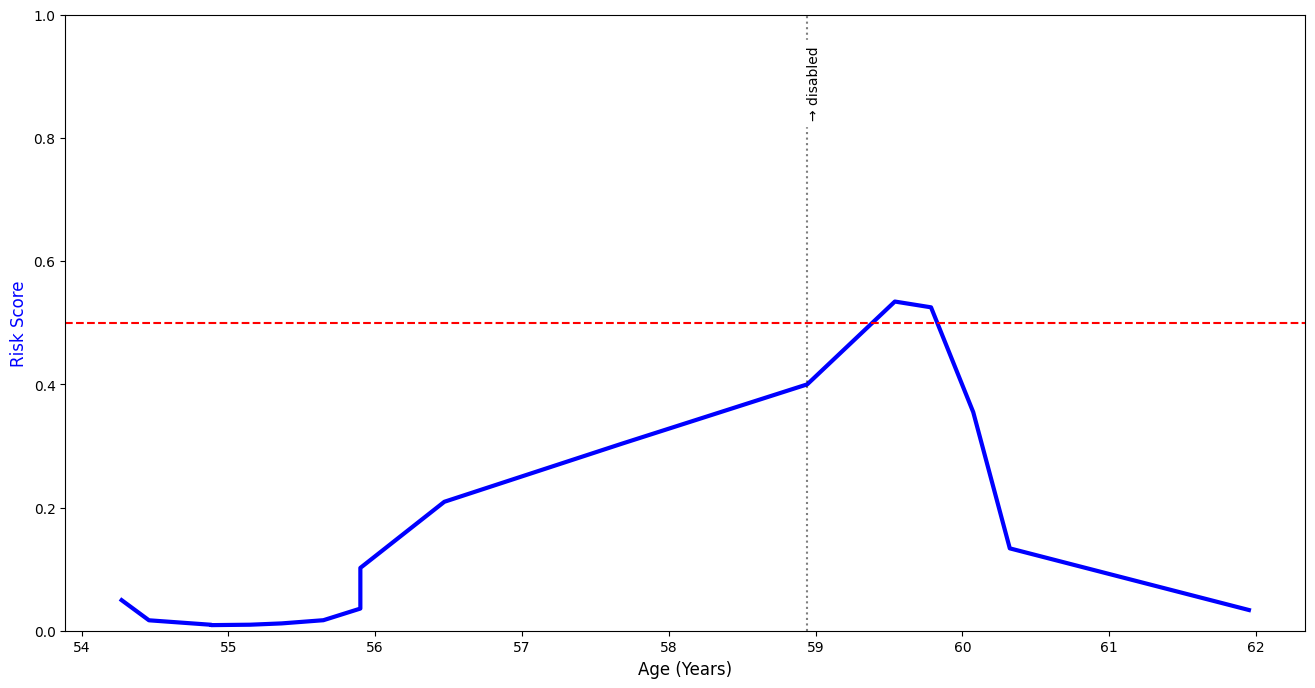

In [79]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Enhanced trajectory plot with employment status markers"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age and time metrics
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    patient_data['Years_from_first_visit'] = (patient_data['ASSDT'] - patient_data['ASSDT'].iloc[0]).dt.days / 365.25
    
    # Get risk predictions
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = patient_data['Age'].values
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.set_ylim(0, 1)
    
    # Mark high-risk threshold
    threshold = risk_df['Threshold_Used'].iloc[0] if 'Threshold_Used' in risk_df.columns else 0.5
    ax1.axhline(y=threshold, color='r', linestyle='--', label='High-Risk Threshold')
    
    # Mark employment status changes
    for i in range(1, len(patient_data)):
        if patient_data['EMPf'].iloc[i] != patient_data['EMPf'].iloc[i-1]:
            age = patient_data['Age'].iloc[i]
            ax1.axvline(x=age, color='k', linestyle=':', alpha=0.5)
            ax1.text(age, 0.95, f"→ {patient_data['EMPf'].iloc[i]}", 
                    ha='left', va='top', rotation=90, backgroundcolor='white')
    
    # Highlight first high-risk flag
    if 'First_High_Risk_Date' in patient_data.columns:
        flag_age = (patient_data['First_High_Risk_Date'].iloc[0] - patient_data['BIRTHDT'].iloc[0]).days / 365.25
        ax1.axvline(x=flag_age, color='g', linestyle='--', alpha=0.7)
        ax1.text(flag_age, 0.9, 'First Flag', rotation=90, ha='right', va='top', color='g')
    
    # Add clinical markers (same as before)
    # ... [rest of your clinical marker plotting code] ...
    
    plt.title(f'Patient {pid} - Employment Trajectory', fontsize=14)
    plt.tight_layout()
    plt.show()

# Convert date columns to datetime if they're strings
date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date', 'Final_Outcome_Date']
for col in date_cols:
    if col in data.columns and data[col].dtype == object:
        data[col] = pd.to_datetime(data[col])
    if col in high_risk_df.columns and high_risk_df[col].dtype == object:
        high_risk_df[col] = pd.to_datetime(high_risk_df[col])
        
# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)

### New Code

In [86]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'severe_flare', 'mild_flare', 
        'ISDOSE', 
        'AMDOSE',
        'STEROID_CAT', 'score_n', 'INCEPT',
        'age_at_record', 'time_since_last', 
        'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2649853129.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2649853129.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])


In [88]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical

# Load and preprocess data
def load_and_preprocess_data(filepath):
    # Load data
    data = pd.read_csv(filepath)
    
    # Convert date column to datetime
    data['ASSDT'] = pd.to_datetime(data['ASSDT'])
    
    # Sort by patient ID and date
    data = data.sort_values(['PTNO', 'ASSDT'])
    
    # Create binary flare indicators
    data['severe_flare'] = (data['severe_flare'] > 0).astype(int)
    data['mild_flare'] = (data['mild_flare'] > 0).astype(int)
    
    # Create immunosuppressant dose level indicator
    data['ISDOSE_high'] = (data['ISDOSE'] > 100).astype(int)
    
    # Define all requested features
    features = [
        'EMP_numeric', 
        'severe_flare', 
        'mild_flare',
        'ISDOSE',
        'ISDOSE_high',  # New binary indicator
        'AMDOSE',
        'STEROID_CAT',  # This should be categorical
        'score_n',
        'INCEPT',
        'age_at_record',
        'time_since_last',
        'time_since_first',
        'visit_num'
    ]
    
    # Handle categorical features (STEROID_CAT)
    if 'STEROID_CAT' in data.columns:
        steroid_categories = ['Low', 'Medium', 'High']  # Adjust based on your actual categories
        data['STEROID_CAT'] = pd.Categorical(data['STEROID_CAT'], categories=steroid_categories)
        steroid_dummies = pd.get_dummies(data['STEROID_CAT'], prefix='STEROID')
        data = pd.concat([data, steroid_dummies], axis=1)
        # Add the dummy columns to our features
        features.extend(steroid_dummies.columns.tolist())
        # Remove the original categorical column
        features.remove('STEROID_CAT')
    
    # Define target variable
    data['end_state'] = data['end_state'].fillna('Unknown')
    
    # Encode target variable
    le = LabelEncoder()
    data['target'] = le.fit_transform(data['end_state'])
    
    return data, features, le

# Create sequences for LSTM
def create_sequences(data, features, max_visits=20):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    # Initialize arrays
    X = np.zeros((len(patients), max_visits, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    # Create sequences for each patient
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        visits = len(patient_data)
        seq_lengths[i] = min(visits, max_visits)
        
        # Get the last max_visits visits
        patient_data = patient_data.tail(max_visits)
        
        # Fill sequence data
        for j in range(min(visits, max_visits)):
            X[i, j, :] = patient_data[features].iloc[j]
        
        # Get target from last visit
        y[i] = patient_data['target'].iloc[-1]
    
    return X, y, seq_lengths

# Main processing function
def prepare_datasets(filepath, test_size=0.2, random_state=42):
    # Load and preprocess data
    data, features, label_encoder = load_and_preprocess_data(filepath)
    
    # Create sequences
    X, y, seq_lengths = create_sequences(data, features)
    
    # Split into train and test
    X_train, X_test, y_train, y_test, seq_train, seq_test = train_test_split(
        X, y, seq_lengths, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Identify binary features (don't scale these)
    binary_features = [
        'severe_flare', 
        'mild_flare', 
        'ISDOSE_high',
        *[col for col in features if col.startswith('STEROID_')]  # Include steroid dummies
    ]
    
    continuous_features = [
        f for f in features 
        if f not in binary_features 
        and f not in ['EMP_numeric']  # EMP_numeric is ordinal
    ]
    
    # Scale continuous features
    scaler = StandardScaler()
    
    # Reshape for scaling
    orig_shape = X_train.shape
    X_train_cont = X_train[:, :, [features.index(f) for f in continuous_features]].reshape(-1, len(continuous_features))
    X_test_cont = X_test[:, :, [features.index(f) for f in continuous_features]].reshape(-1, len(continuous_features))
    
    # Scale continuous features
    scaler.fit(X_train_cont)
    X_train_cont_scaled = scaler.transform(X_train_cont)
    X_test_cont_scaled = scaler.transform(X_test_cont)
    
    # Reshape back
    X_train[:, :, [features.index(f) for f in continuous_features]] = X_train_cont_scaled.reshape(
        orig_shape[0], orig_shape[1], len(continuous_features))
    X_test[:, :, [features.index(f) for f in continuous_features]] = X_test_cont_scaled.reshape(
        (X_test.shape[0], X_test.shape[1], len(continuous_features)))
    
    # Convert y to categorical
    num_classes = len(label_encoder.classes_)
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_test_cat = to_categorical(y_test, num_classes=num_classes)
    
    # Compute class weights
    class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train_cat,
        'y_test': y_test_cat,
        'seq_lengths_train': seq_train,
        'seq_lengths_test': seq_test,
        'features': features,
        'label_encoder': label_encoder,
        'scaler': scaler,
        'class_weight_dict': class_weight_dict,
        'data': data  # Return the full dataframe for analysis
    }

# Load your data
filepath = "sledatacut.csv"
data_prepared = prepare_datasets(filepath)

# Extract the prepared datasets
X_train = data_prepared['X_train']
X_test = data_prepared['X_test']
y_train = data_prepared['y_train']
y_test = data_prepared['y_test']
seq_lengths_train = data_prepared['seq_lengths_train']
seq_lengths_test = data_prepared['seq_lengths_test']
features = data_prepared['features']
label_encoder = data_prepared['label_encoder']
scaler = data_prepared['scaler']
class_weight_dict = data_prepared['class_weight_dict']
data = data_prepared['data']

# Verify shapes and features
print("Data shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"\nFeatures used ({len(features)}):")
print(features)
print(f"\nClass weights: {class_weight_dict}")
print(f"Target classes: {list(label_encoder.classes_)}")

# [Rest of your model training and evaluation code remains the same]

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/2993949002.py:11: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


Data shapes:
X_train: (820, 20, 15)
X_test: (205, 20, 15)
y_train: (820, 6)
y_test: (205, 6)

Features used (15):
['EMP_numeric', 'severe_flare', 'mild_flare', 'ISDOSE', 'ISDOSE_high', 'AMDOSE', 'score_n', 'INCEPT', 'age_at_record', 'time_since_last', 'time_since_first', 'visit_num', 'STEROID_Low', 'STEROID_Medium', 'STEROID_High']

Class weights: {0: 1.3268608414239482, 1: 6.507936507936508, 2: 4.880952380952381, 3: 0.22404371584699453, 4: 6.212121212121212, 5: 3.7962962962962963}
Target classes: ['Disability Benefit', 'Early Retirement', 'Economically Inactive', 'Employed', 'Employed (Died)', 'Unemployed']


In [95]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Load the data - removed duplicate load
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flares', 'mild_flares', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n']  # Added score_n (SDI)

# Add total flares feature
data['total_flares'] = data['severe_flares'] + data['mild_flares']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flares']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']

# Add temporal features
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1)  # +1 to avoid division by zero

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 
             'flares_per_month', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flares', 'mild_flares']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
# [Previous data loading and preprocessing code remains the same until sequence creation]

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    
    # Calculate class weights
    classes = np.unique(np.argmax(y_train, axis=1))
    class_weights = compute_class_weight('balanced', classes=classes, y=np.argmax(y_train, axis=1))
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build model
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions
final_pred = 0.7 * test_preds + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_37170/1511124725.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(



Training fold 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 523ms/step - accuracy: 0.2406 - loss: 4.4535 - val_accuracy: 0.1096 - val_loss: 4.0087 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 559ms/step - accuracy: 0.3154 - loss: 3.8339 - val_accuracy: 0.3026 - val_loss: 3.8001 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 397ms/step - accuracy: 0.3623 - loss: 3.2947 - val_accuracy: 0.3158 - val_loss: 3.6071 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 565ms/step - accuracy: 0.4636 - loss: 3.0571 - val_accuracy: 0.3289 - val_loss: 3.4168 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 435ms/step - accuracy: 0.4983 - loss: 2.7978 - val_accuracy: 0.4737 - val_loss: 3.2201 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step - accuracy: 0.4946 - loss: 2.5938 - val_accuracy: 0.3114 - val_loss: 3.0828 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - accuracy: 0.5076 - l

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 528ms/step - accuracy: 0.3991 - loss: 4.6729 - val_accuracy: 0.1623 - val_loss: 4.0645 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 369ms/step - accuracy: 0.4255 - loss: 3.8124 - val_accuracy: 0.1886 - val_loss: 3.8636 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.4440 - loss: 3.3067 - val_accuracy: 0.1667 - val_loss: 3.7043 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.4721 - loss: 2.9901 - val_accuracy: 0.1754 - val_loss: 3.5315 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.4422 - loss: 2.8647 - val_accuracy: 0.1754 - val_loss: 3.3607 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.5171 - loss: 2.6213 - val_accuracy: 0.2018 - val_loss: 3.1906 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 497ms/step - accuracy: 0.5788 - loss

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 541ms/step - accuracy: 0.2601 - loss: 4.6692 - val_accuracy: 0.0482 - val_loss: 4.0693 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 546ms/step - accuracy: 0.3852 - loss: 3.7346 - val_accuracy: 0.1447 - val_loss: 3.8617 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4024 - loss: 3.3082 - val_accuracy: 0.1798 - val_loss: 3.6865 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 442ms/step - accuracy: 0.4268 - loss: 3.2133 - val_accuracy: 0.3158 - val_loss: 3.5030 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 437ms/step - accuracy: 0.5131 - loss: 2.8433 - val_accuracy: 0.2851 - val_loss: 3.3428 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 771ms/step - accuracy: 0.4935 - loss: 2.7850 - val_accuracy: 0.3816 - val_loss: 3.1686 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step - accuracy: 0.5408 - loss

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.1231 - loss: 4.6795 - val_accuracy: 0.0877 - val_loss: 4.0433 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.2908 - loss: 3.8164 - val_accuracy: 0.1623 - val_loss: 3.8687 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.3477 - loss: 3.5851 - val_accuracy: 0.1096 - val_loss: 3.7127 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.3928 - loss: 3.2268 - val_accuracy: 0.1754 - val_loss: 3.5442 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step - accuracy: 0.4573 - loss: 3.0211 - val_accuracy: 0.2149 - val_loss: 3.3950 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.4697 - loss: 2.8111 - val_accuracy: 0.2500 - val_loss: 3.2446 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.4798 - loss: 2

In [96]:

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))


Final Ensemble Evaluation Metrics:
Balanced Accuracy: 0.766
Cohen's Kappa: 0.832

Classification Report:
                       precision    recall  f1-score   support

   Disability Benefit       0.90      0.79      0.84        77
     Early Retirement       0.69      0.82      0.75        11
Economically Inactive       0.95      0.95      0.95        43
             Employed       0.94      0.95      0.94       132
      Employed (Died)       0.33      0.20      0.25         5
           Unemployed       0.60      0.88      0.71        17

             accuracy                           0.88       285
            macro avg       0.74      0.77      0.74       285
         weighted avg       0.89      0.88      0.88       285


Confusion Matrix:
[[ 61   1   2   3   0  10]
 [  1   9   0   1   0   0]
 [  2   0  41   0   0   0]
 [  2   3   0 125   2   0]
 [  0   0   0   4   1   0]
 [  2   0   0   0   0  15]]

Top 10 Important Features:
                      Feature  Importance
0        

In [108]:
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Predict risk scores for each time point in patient data"""
    # Prepare sequence data for this patient
    num_features = len(features)
    seq_len = len(patient_data)
    
    X_patient = np.zeros((1, max_seq_length, num_features))
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get predictions for each time point
    predictions = []
    for i in range(1, seq_len + 1):
        partial_seq = X_patient.copy()
        partial_seq[0, i:, :] = 0  # Mask future data
        pred = model.predict(partial_seq, verbose=0)[0]
        predictions.append(pred[1])  # Probability of class 1 (exit)
    
    # Create result DataFrame
    result = patient_data[['ASSDT', 'end_state', 'EMPf']].copy()
    result['Risk_Score'] = predictions
    result['SLEDAI'] = patient_data['SLEDAI2_I'] if 'SLEDAI2_I' in patient_data else 0
    result['Steroid_Dose'] = patient_data['STERDOSE'] if 'STERDOSE' in patient_data else 0
    result['SDI'] = patient_data['score_n']
    result['Immunosuppressant'] = patient_data['ISDOSE']
    result['Employment_Status'] = patient_data['EMPf']
    
    return result

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced clinical criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Enhanced threshold rules with clinical hierarchy
    THRESHOLD_RULES = [
        # Tier 1: Acute crisis indicators (highest priority)
        {'conditions': {
            'severe_flares': lambda x: x >= 1,
            'STEROID_CAT_numeric': lambda x: x >= 2,  # High-dose steroids
            'SLEDAI2_I': lambda x: x >= 12
         },
         'risk_threshold': 0.25,
         'tier': 'acute_crisis'},
        
        # Tier 2: Progressive disease markers
        {'conditions': {
            'mild_flares': lambda x: x >= 2,
            'score_n': lambda x: x >= 1,
            'ISDOSE': lambda x: x >= 100,
            'STERDOSE': lambda x: x >= 15
         },
         'risk_threshold': 0.3,
         'tier': 'progressive_disease'},
        
        # Tier 3: Employment-specific early warning
        {'conditions': {
            'EMP_numeric': lambda x: x == 1,  # Employed status
            'AMDOSE': lambda x: x >= 50,  # Antimalarials as stability marker
            'INCEPT': lambda x: x < 5  # Recent diagnosis (<5 years)
         },
         'risk_threshold': 0.2,
         'tier': 'employment_early_warning'},
        
        # Tier 4: General deterioration
        {'conditions': {
            'STEROID_CAT_numeric': lambda x: x >= 1,
            'SLEDAI2_I': lambda x: x >= 6,
            'ISDOSE': lambda x: x >= 50
         },
         'risk_threshold': 0.35,
         'tier': 'general_deterioration'},
        
        # Default threshold
        {'default': True,
         'risk_threshold': 0.45,
         'tier': 'baseline_risk'}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply clinical judgment hierarchy
            applied_threshold = None
            applied_tier = None
            
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    if applied_threshold is None:  # Only use default if no other rules matched
                        applied_threshold = rule['risk_threshold']
                        applied_tier = rule['tier']
                    continue
                
                conditions_met = True
                for k, f in rule['conditions'].items():
                    if k not in current_data:
                        conditions_met = False
                        break
                    if not f(current_data[k]):
                        conditions_met = False
                        break
                
                if conditions_met and (applied_threshold is None or rule['risk_threshold'] < applied_threshold):
                    applied_threshold = rule['risk_threshold']
                    applied_tier = rule['tier']
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold,
                    'tier': applied_tier,
                    'months_employed': current_data.get('EMPLOYMENT_DURATION', np.nan),
                    'flares_past_year': current_data.get('FLARES_12MO', 0)
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prefer earlier warnings for employed patients
            employed_warnings = [w for w in warning_points 
                                if w['context']['EMP_numeric'] == 1]
            
            if employed_warnings:
                # Select earliest warning for employed patients
                employed_warnings.sort(key=lambda x: x['date'])
                best_warning = employed_warnings[0]
            else:
                # For non-employed, select warning with strongest clinical basis
                warning_points.sort(key=lambda x: (
                    -x['risk'],  # Highest risk first
                    x['tier'] != 'acute_crisis',  # Prefer acute crisis warnings
                    x['date']  # Then earliest warning
                ))
                best_warning = warning_points[0]
            
            final_status_date = patient_data['ASSDT'].iloc[-1]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Include all warnings with clinical rationale
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': best_warning['date'],
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'Risk_Score': best_warning['risk'],
                'Threshold_Used': best_warning['threshold'],
                'Warning_Tier': best_warning['tier'],
                'SLEDAI_at_Warning': best_warning['context'].get('SLEDAI2_I', np.nan),
                'Steroid_at_Warning': best_warning['context'].get('STERDOSE', np.nan),
                'SDI_at_Warning': best_warning['context']['score_n'],
                'ISDOSE_at_Warning': best_warning['context']['ISDOSE'],
                'AMDOSE_at_Warning': best_warning['context'].get('AMDOSE', 0),
                'Severe_Flares': best_warning['context'].get('severe_flares', 0),
                'Mild_Flares': best_warning['context'].get('mild_flares', 0),
                'Steroid_Category': best_warning['context']['STEROID_CAT_numeric'],
                'Disease_Duration': best_warning['context']['INCEPT'],
                'Employment_at_Warning': best_warning['context']['EMPf'],
                'Months_Prior_to_Exit': months_prior,
                'Warning_Type': 'Early' if months_prior > 12 else ('Imminent' if months_prior > 3 else 'Critical')
            })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Initialize unscaled columns
    for col in ['SLEDAI_unscaled', 'Steroid_unscaled', 'SDI_unscaled', 'Immunosuppressant_unscaled']:
        high_risk_df[col] = np.nan
    
    # Only attempt inverse transform if we have the features
    available_features = [f for f in warning_to_feature.values() if f in feature_pos]
    if available_features:
        # Create a temporary array for inverse transform
        temp_array = np.zeros((len(high_risk_df), len(features)))
        
        # Fill the temporary array with scaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
        
        # Apply inverse transformation
        unscaled_array = scaler.inverse_transform(temp_array)
        
        # Extract the unscaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                high_risk_df[f"{warning_col.split('_')[0]}_unscaled"] = unscaled_array[:, feature_pos[feat]]
    
    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)} patients flagged as high risk",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'High_SDI': f"{len(high_risk_df[high_risk_df['SDI_at_Warning'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_at_Warning'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'Employment_Status': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': high_risk_df['SDI_at_Warning'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_at_Warning'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in high_risk_df.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = f"{len(high_risk_df[high_risk_df['SLEDAI_at_Warning'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = high_risk_df['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in high_risk_df.columns:
        report['Common_Triggers']['High_Steroids'] = f"{len(high_risk_df[high_risk_df['Steroid_at_Warning'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = high_risk_df['Steroid_at_Warning'].median()
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

# Main execution
if __name__ == "__main__":
    # Convert birth date if exists
    if 'BIRTHDT' in data.columns:
        data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
    
    # Get high risk patients
    high_risk_df = get_high_risk_patients(model, data, features)
    
    # Generate and print report
    if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)
        
        print("\n=== Clinical Report ===")
        print(f"High Risk Patients Detected: {len(high_risk_df)}")
        print(f"Median Warning Time: {clinical_report['Median_Warning_Time']}")
        
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")
            
              
        # Print comprehensive clinical report
        print("\n=== Actionable Clinical Insights ===")
        print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
        print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
        print("\nKey Predictors of Labor Force Exit:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
        print("\nMedian Values at Warning Point:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")

    else:
        print("No high-risk patients detected.")

KeyError: 'Immunosuppressant_at_Warning'

In [114]:
def generate_clinical_report(high_risk_df, scaler, features, original_data):
    """Enhanced clinical report with proper unique patient counting"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Ensure we're working with unique patients in both datasets
    high_risk_unique = high_risk_df.drop_duplicates('PTNO')
    original_unique = original_data.drop_duplicates('PTNO')
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n'
    }
    
    # Initialize unscaled columns
    for col in ['SLEDAI_unscaled', 'Steroid_unscaled', 'SDI_unscaled']:
        high_risk_df[col] = np.nan
    
    # Only attempt inverse transform if we have the features
    available_features = [f for f in warning_to_feature.values() if f in feature_pos]
    if available_features:
        # Create a temporary array for inverse transform
        temp_array = np.zeros((len(high_risk_df), len(features)))
        
        # Fill the temporary array with scaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
        
        # Apply inverse transformation
        unscaled_array = scaler.inverse_transform(temp_array)
        
        # Extract the unscaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                high_risk_df[f"{warning_col.split('_')[0]}_unscaled"] = unscaled_array[:, feature_pos[feat]]
    
    # Calculate total unique patients who should have been flagged (non-employed outcomes)
    target_population = original_unique[~original_unique['end_state'].str.contains('Employed', case=False, na=False)]
    total_should_flag = len(target_population['PTNO'].unique())
    n_detected = len(high_risk_unique)
    
    # Identify employed patients at time of warning (using first warning per patient)
    first_warnings = high_risk_df.sort_values('First_High_Risk_Date').drop_duplicates('PTNO')
    employed_mask = first_warnings['Employment_at_Warning'].str.contains('employed', case=False, na=False)
    employed_df = first_warnings[employed_mask]
    
    # Enhanced report with proper unique patient counting
    report = {
        'Detection_Rate': {
            'Total_Detected': n_detected,
            'Total_Should_Detect': total_should_flag,
            'Detection_Percentage': f"{n_detected/total_should_flag:.1%}" if total_should_flag > 0 else "N/A",
            'Median_Warning_Time': f"{first_warnings['Months_Prior_to_Exit'].median()} months before exit"
        },
        'Common_Triggers': {
            'High_SDI': f"{len(first_warnings[first_warnings['SDI_at_Warning'] >= 1])/n_detected:.0%} had SDI ≥1",
            'Employment_Status': f"{len(first_warnings[~employed_mask])/n_detected:.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': first_warnings['SDI_at_Warning'].median()
        },
        'Accuracy_by_Outcome': {},
        'Employment_Specific': {
            'N_Employed_At_Warning': len(employed_df),
            'Pct_Employed_At_Warning': f"{len(employed_df)/n_detected:.1%}",
            'Warning_Time_Distribution': {}
        }
    }
    
    # Add detailed warning time distribution for employed patients
    if len(employed_df) > 0:
        report['Employment_Specific'].update({
            'Median_Warning_Time_Employed': f"{employed_df['Months_Prior_to_Exit'].median()} months",
            'Mean_Warning_Time_Employed': f"{employed_df['Months_Prior_to_Exit'].mean():.1f} months",
            'Min_Warning_Time_Employed': f"{employed_df['Months_Prior_to_Exit'].min()} months",
            'Max_Warning_Time_Employed': f"{employed_df['Months_Prior_to_Exit'].max()} months"
        })
        
        time_bins = [0, 3, 6, 12, 24, 60, float('inf')]
        bin_labels = ['<3', '3-6', '6-12', '12-24', '24-60', '60+']
        time_dist = pd.cut(employed_df['Months_Prior_to_Exit'], 
                         bins=time_bins, 
                         labels=bin_labels).value_counts().sort_index()
        
        for bin_label, count in time_dist.items():
            report['Employment_Specific']['Warning_Time_Distribution'][f"Months_{bin_label}"] = \
                f"{count} patients ({count/len(employed_df):.1%})"
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = \
            f"{len(first_warnings[first_warnings['SLEDAI_at_Warning'] >= 4])/n_detected:.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = first_warnings['SLEDAI_at_Warning'].median()
        
        if len(employed_df) > 0:
            report['Employment_Specific']['Median_SLEDAI_Employed'] = \
                employed_df['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_Steroids'] = \
            f"{len(first_warnings[first_warnings['Steroid_at_Warning'] >= 7.5])/n_detected:.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = first_warnings['Steroid_at_Warning'].median()
        
        if len(employed_df) > 0:
            report['Employment_Specific']['Median_Steroid_Employed'] = \
                employed_df['Steroid_at_Warning'].median()
    
    # Calculate accuracy by outcome using unique patients
    if 'end_state' in original_unique.columns:
        outcome_counts = original_unique['end_state'].value_counts()
        detected_outcomes = first_warnings['Final_Outcome'].value_counts()
        
        for outcome in detected_outcomes.index:
            n_correct = detected_outcomes[outcome]
            n_total = outcome_counts.get(outcome, 0)
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = {
                    'Detected': n_correct,
                    'Total': n_total,
                    'Percentage': f"{n_correct/n_total:.1%}"
                }
    
    return report, high_risk_df


# Main execution
if __name__ == "__main__":
    # Generate and print report
    if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features, data)
        
        print("\n=== DETECTION RATE ANALYSIS (UNIQUE PATIENTS) ===")
        det_rate = clinical_report['Detection_Rate']
        print(f"Unique patients detected as high risk: {det_rate['Total_Detected']}")
        print(f"Total unique patients who should be flagged (non-employed outcomes): {det_rate['Total_Should_Detect']}")
        print(f"Detection rate: {det_rate['Detection_Percentage']}")
        print(f"Median warning time: {det_rate['Median_Warning_Time']}")
        
        print("\n=== CLINICAL CHARACTERISTICS ===")
        print("\nKey Predictors at First Warning:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at First Warning:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")
            
        print("\n=== EMPLOYMENT-SPECIFIC ANALYSIS ===")
        emp_stats = clinical_report['Employment_Specific']
        print(f"\nPatients flagged while still employed: {emp_stats['N_Employed_At_Warning']} ({emp_stats['Pct_Employed_At_Warning']})")
        
        if emp_stats['N_Employed_At_Warning'] > 0:
            print("\nWarning Time Distribution (Employed Patients):")
            print(f"- Median: {emp_stats['Median_Warning_Time_Employed']}")
            print(f"- Mean: {emp_stats['Mean_Warning_Time_Employed']}")
            print(f"- Range: {emp_stats['Min_Warning_Time_Employed']} to {emp_stats['Max_Warning_Time_Employed']}")
            
            print("\nTime Before Exit:")
            for bin_label, dist in emp_stats['Warning_Time_Distribution'].items():
                print(f"- {bin_label.replace('_', ' ')} months: {dist}")
            
            if 'Median_SLEDAI_Employed' in emp_stats:
                print(f"- Median SLEDAI at warning: {emp_stats['Median_SLEDAI_Employed']:.1f}")
            if 'Median_Steroid_Employed' in emp_stats:
                print(f"- Median Steroid at warning: {emp_stats['Median_Steroid_Employed']:.1f} mg")
        
        print("\nEmployment Status at First Warning:\n", high_risk_df.drop_duplicates('PTNO')['Employment_at_Warning'].value_counts())
        
        print("\n=== ACCURACY BY OUTCOME ===")
        for outcome, stats in clinical_report['Accuracy_by_Outcome'].items():
            print(f"{outcome}: {stats['Detected']}/{stats['Total']} ({stats['Percentage']}) detected")
      
        print("\n=== ACTIONABLE INSIGHTS ===")
        print(f"\nModel performance (unique patients):")
        print(f"- Detected {det_rate['Total_Detected']} of {det_rate['Total_Should_Detect']} at-risk patients ({det_rate['Detection_Percentage']})")
        print(f"- {emp_stats['N_Employed_At_Warning']} warnings issued while patients were still employed")
        
        if emp_stats['N_Employed_At_Warning'] > 0:
            print(f"- Earliest warning for employed patients: {emp_stats['Max_Warning_Time_Employed']} months before exit")

    else:
        print("No high-risk patients detected.")


=== DETECTION RATE ANALYSIS (UNIQUE PATIENTS) ===
Unique patients detected as high risk: 128
Total unique patients who should be flagged (non-employed outcomes): 656
Detection rate: 19.5%
Median warning time: 10.0 months before exit

=== CLINICAL CHARACTERISTICS ===

Key Predictors at First Warning:
- 0% had SDI ≥1
- 88% showed work status decline
- 34% had SLEDAI ≥4
- 32% on ≥7.5mg prednisone

Median Values at First Warning:
- SDI: 0.07
- SLEDAI: 2.00
- Steroid_Dose: 10.00

=== EMPLOYMENT-SPECIFIC ANALYSIS ===

Patients flagged while still employed: 15 (11.7%)

Warning Time Distribution (Employed Patients):
- Median: 45.0 months
- Mean: 75.9 months
- Range: 0 months to 299 months

Time Before Exit:
- Months <3 months: 0 patients (0.0%)
- Months 3-6 months: 0 patients (0.0%)
- Months 6-12 months: 2 patients (13.3%)
- Months 12-24 months: 0 patients (0.0%)
- Months 24-60 months: 5 patients (33.3%)
- Months 60+ months: 7 patients (46.7%)
- Median SLEDAI at warning: 1.0
- Median Steroid 

In [109]:

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n'
        }
    
    # Initialize unscaled columns
    for col in ['SLEDAI_unscaled', 'Steroid_unscaled', 'SDI_unscaled']:
        high_risk_df[col] = np.nan
    
    # Only attempt inverse transform if we have the features
    available_features = [f for f in warning_to_feature.values() if f in feature_pos]
    if available_features:
        # Create a temporary array for inverse transform
        temp_array = np.zeros((len(high_risk_df), len(features)))
        
        # Fill the temporary array with scaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
        
        # Apply inverse transformation
        unscaled_array = scaler.inverse_transform(temp_array)
        
        # Extract the unscaled values
        for warning_col, feat in warning_to_feature.items():
            if warning_col in high_risk_df.columns and feat in feature_pos:
                high_risk_df[f"{warning_col.split('_')[0]}_unscaled"] = unscaled_array[:, feature_pos[feat]]
    
    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)} patients flagged as high risk",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'High_SDI': f"{len(high_risk_df[high_risk_df['SDI_at_Warning'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Status': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': high_risk_df['SDI_at_Warning'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in high_risk_df.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = f"{len(high_risk_df[high_risk_df['SLEDAI_at_Warning'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = high_risk_df['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in high_risk_df.columns:
        report['Common_Triggers']['High_Steroids'] = f"{len(high_risk_df[high_risk_df['Steroid_at_Warning'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = high_risk_df['Steroid_at_Warning'].median()
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

# Main execution
if __name__ == "__main__":

    # Generate and print report
    if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)
        
        print("\n=== Clinical Report ===")
        print(f"High Risk Patients Detected: {len(high_risk_df)}")
        print(f"Median Warning Time: {clinical_report['Median_Warning_Time']}")
        
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")
            
        print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())
      
        # Print comprehensive clinical report
        print("\n=== Actionable Clinical Insights ===")
        print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
        print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
        print("\nKey Predictors of Labor Force Exit:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
        print("\nMedian Values at Warning Point:")
        for k, v in clinical_report['Median_Values'].items():
            print(f"- {k}: {v:.2f}")

    else:
        print("No high-risk patients detected.")


=== Clinical Report ===
High Risk Patients Detected: 128
Median Warning Time: 10.0 months before exit

Key Predictors:
- 0% had SDI ≥1
- 88% showed work status decline
- 34% had SLEDAI ≥4
- 32% on ≥7.5mg prednisone

Median Values at Warning:
- SDI: 0.07
- SLEDAI: 2.00
- Steroid_Dose: 10.00

Employment Status:
 Employment_at_Warning
retired       94
employed      15
disabled      15
homemaker      3
sick leave     1
Name: count, dtype: int64

=== Actionable Clinical Insights ===
Early Warning: Model flagged 128 patients at high risk
Median lead time: 10.0 months before exit

Key Predictors of Labor Force Exit:
- 0% had SDI ≥1
- 88% showed work status decline
- 34% had SLEDAI ≥4
- 32% on ≥7.5mg prednisone

Median Values at Warning Point:
- SDI: 0.07
- SLEDAI: 2.00
- Steroid_Dose: 10.00



Visualizing High-Risk Patient Trajectories (Age on X-axis)...


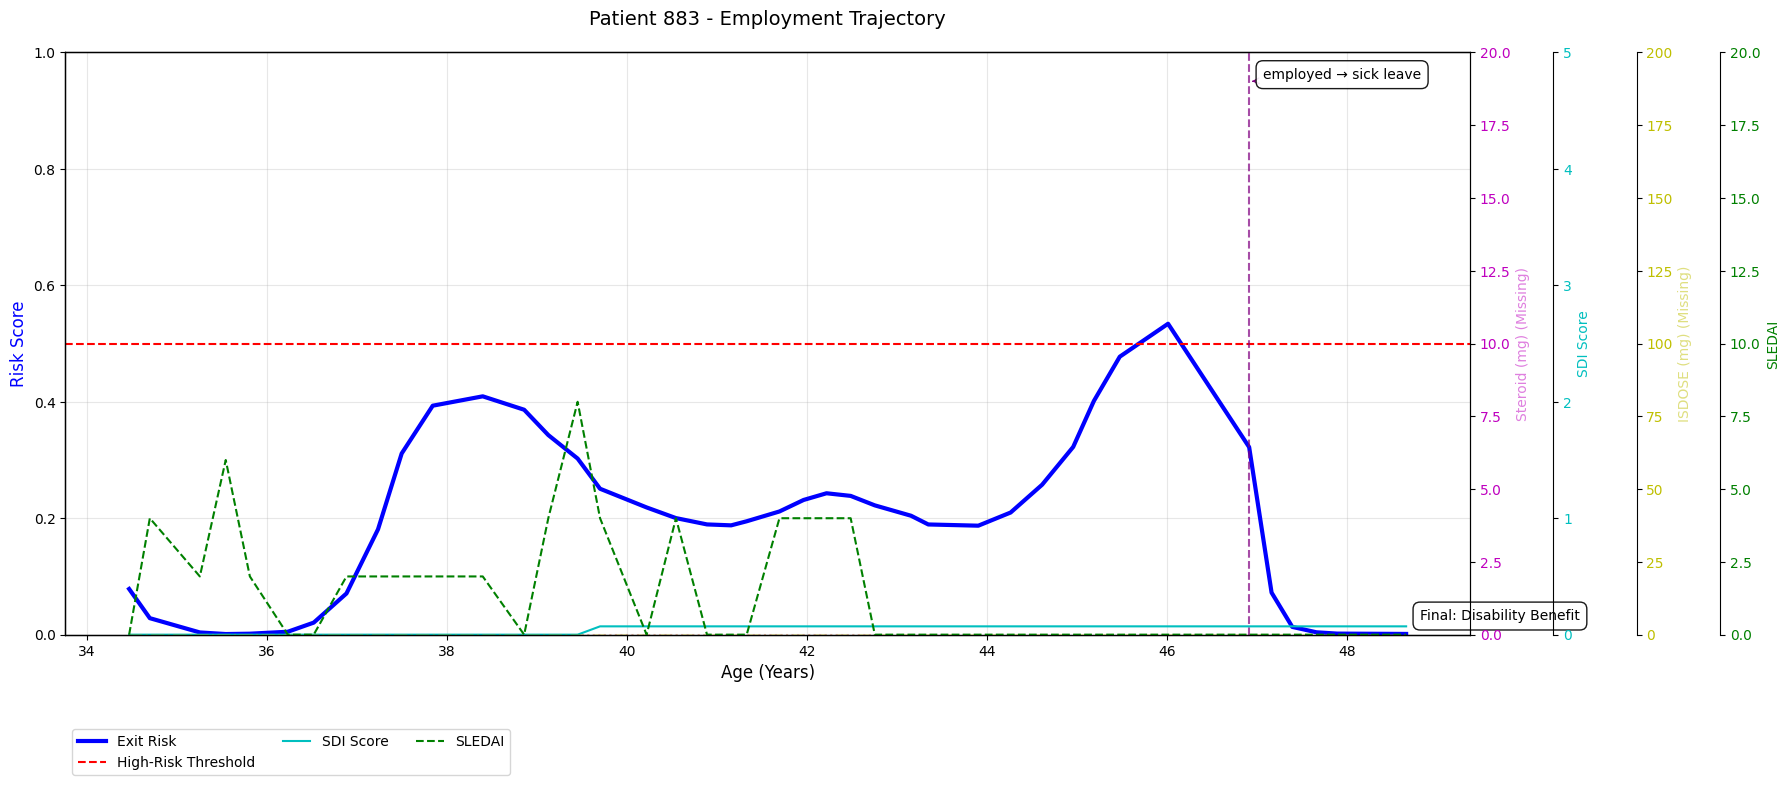

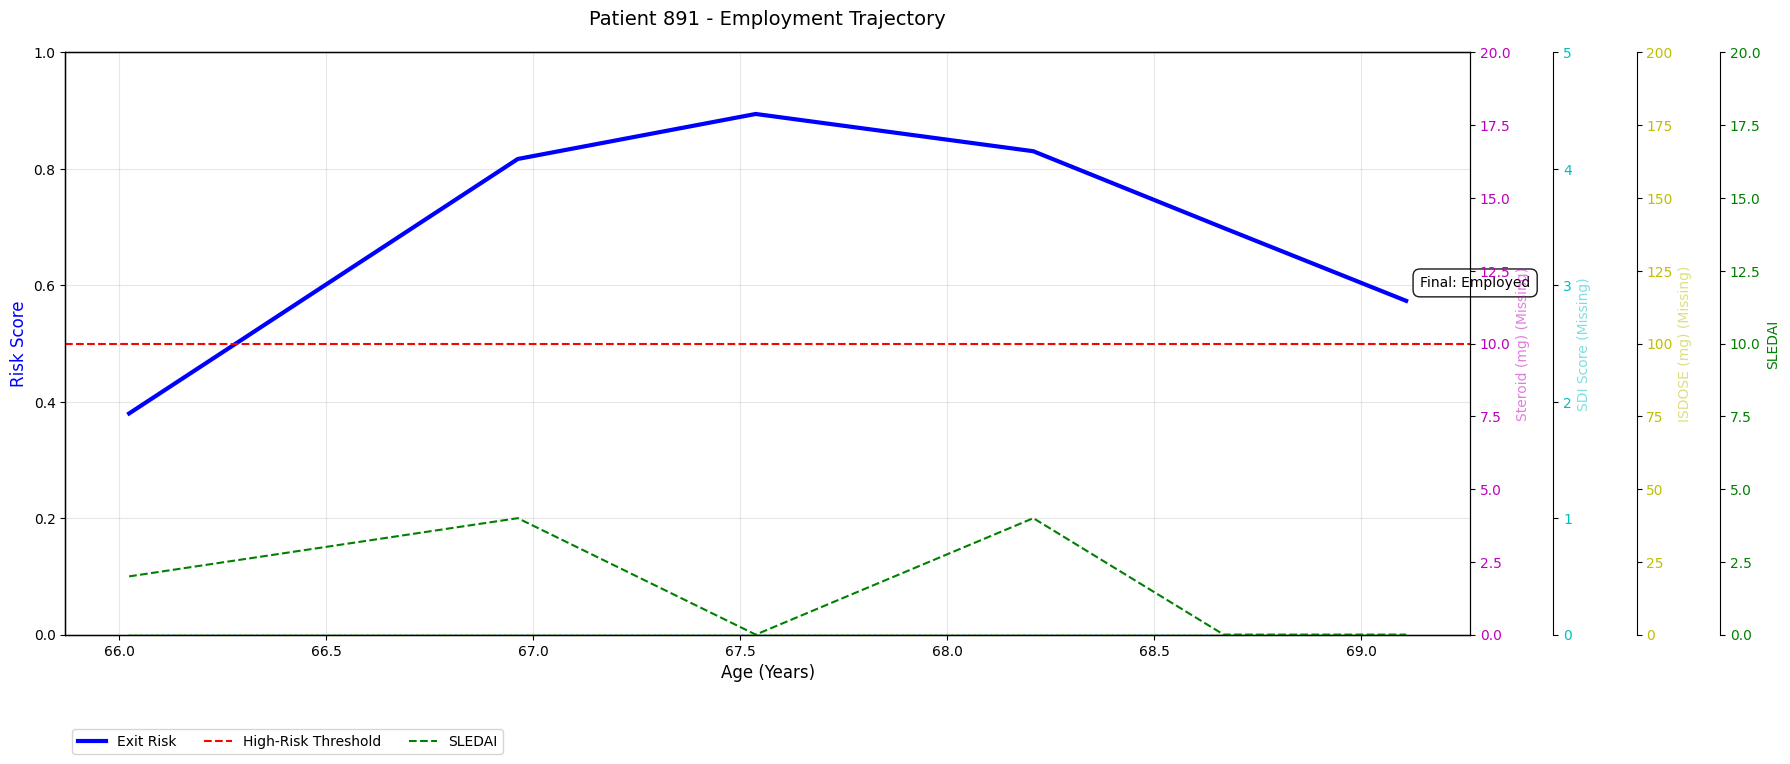

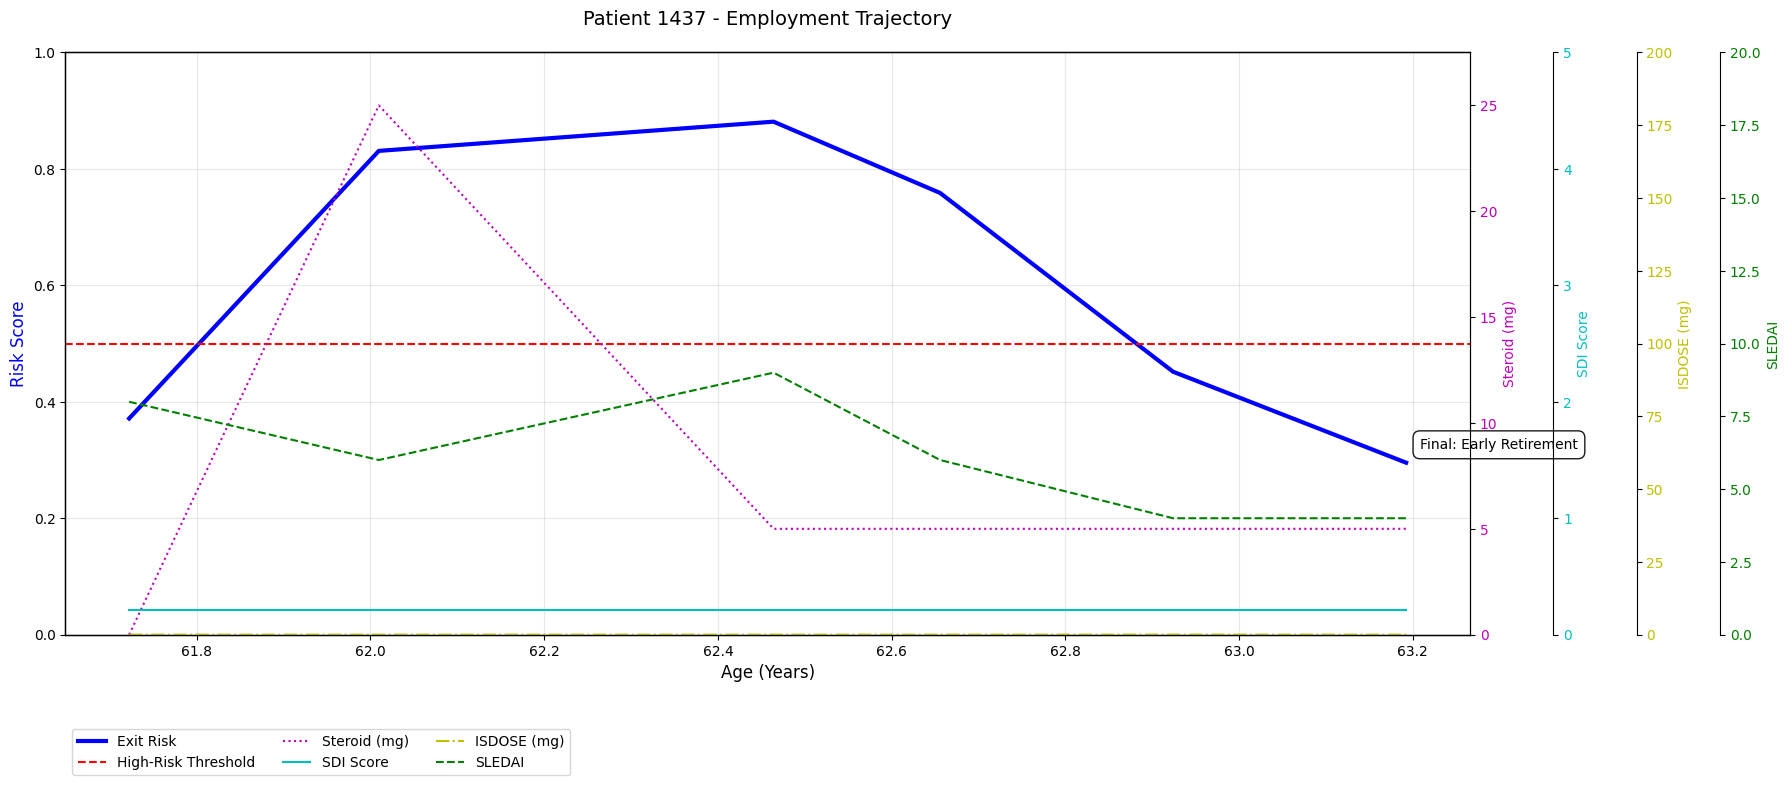

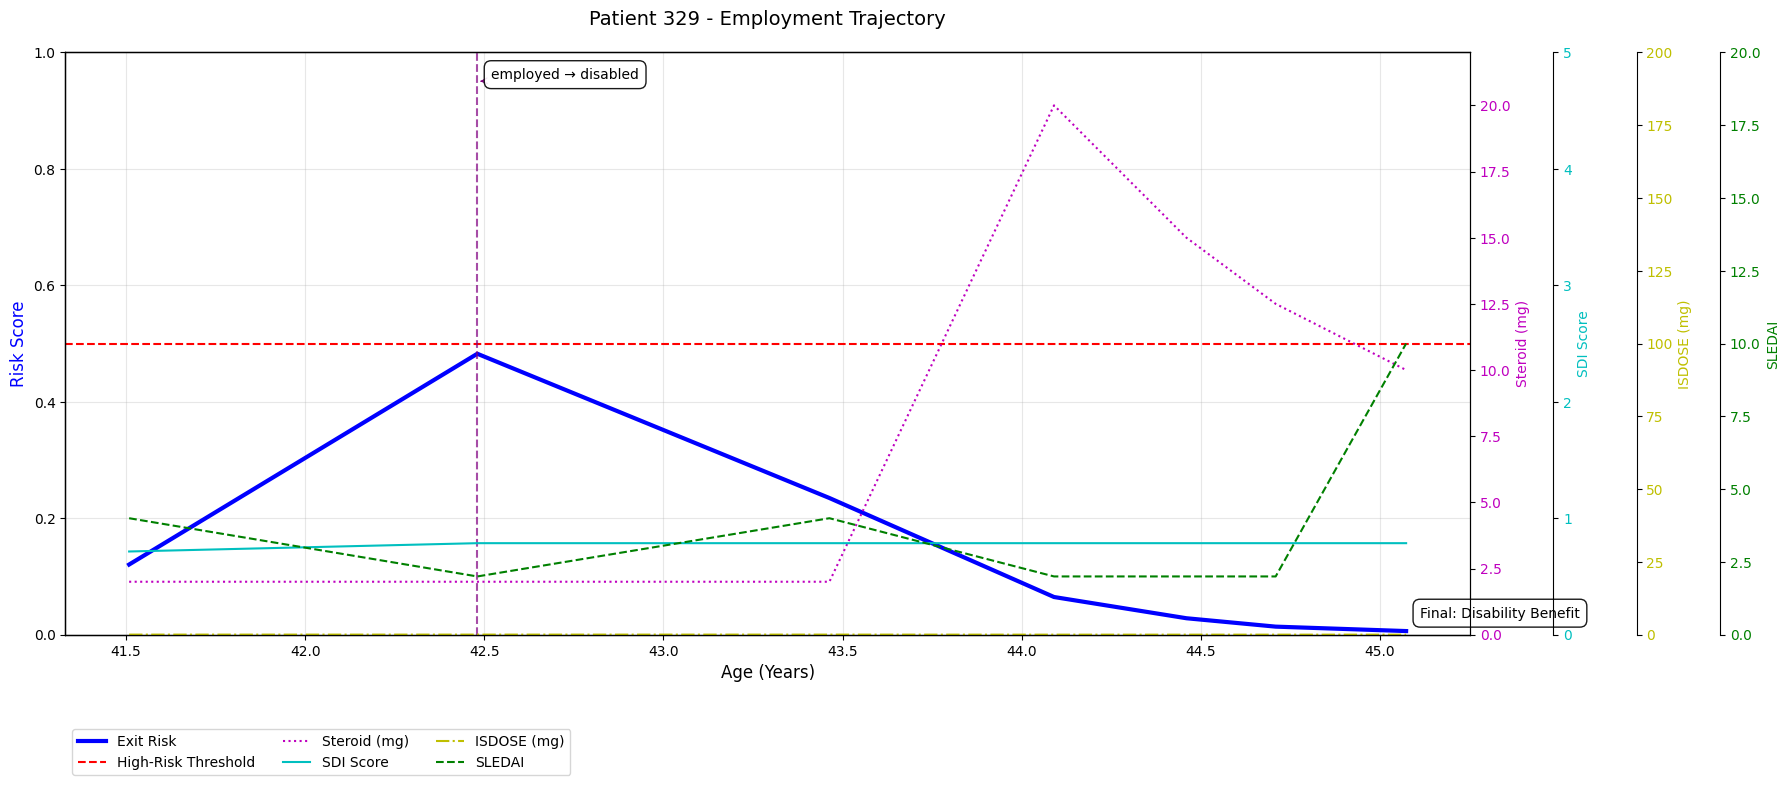

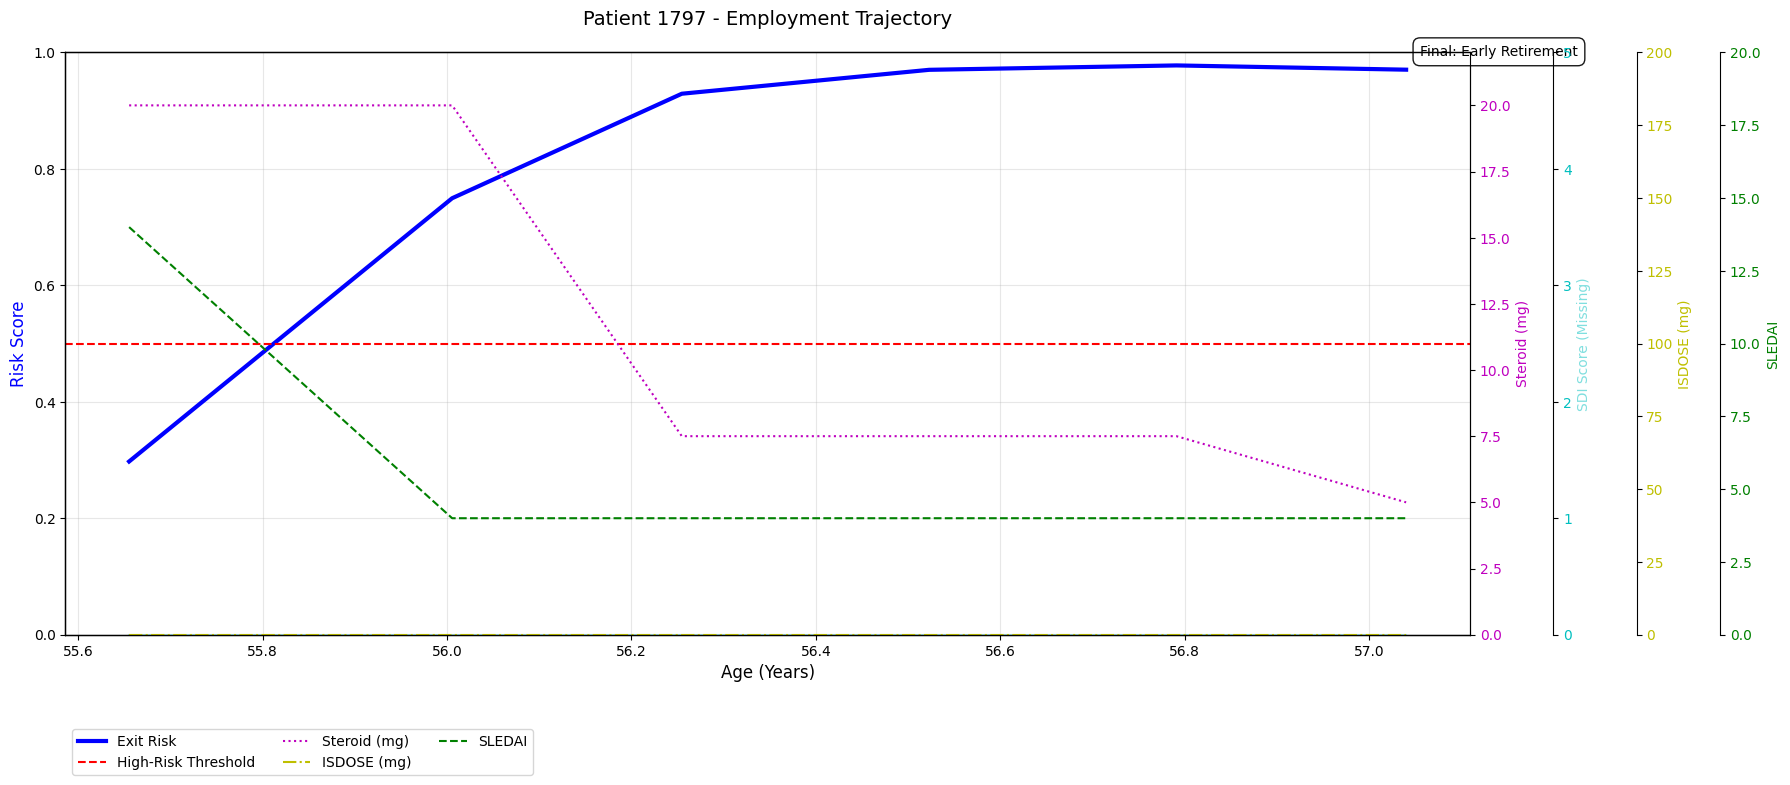

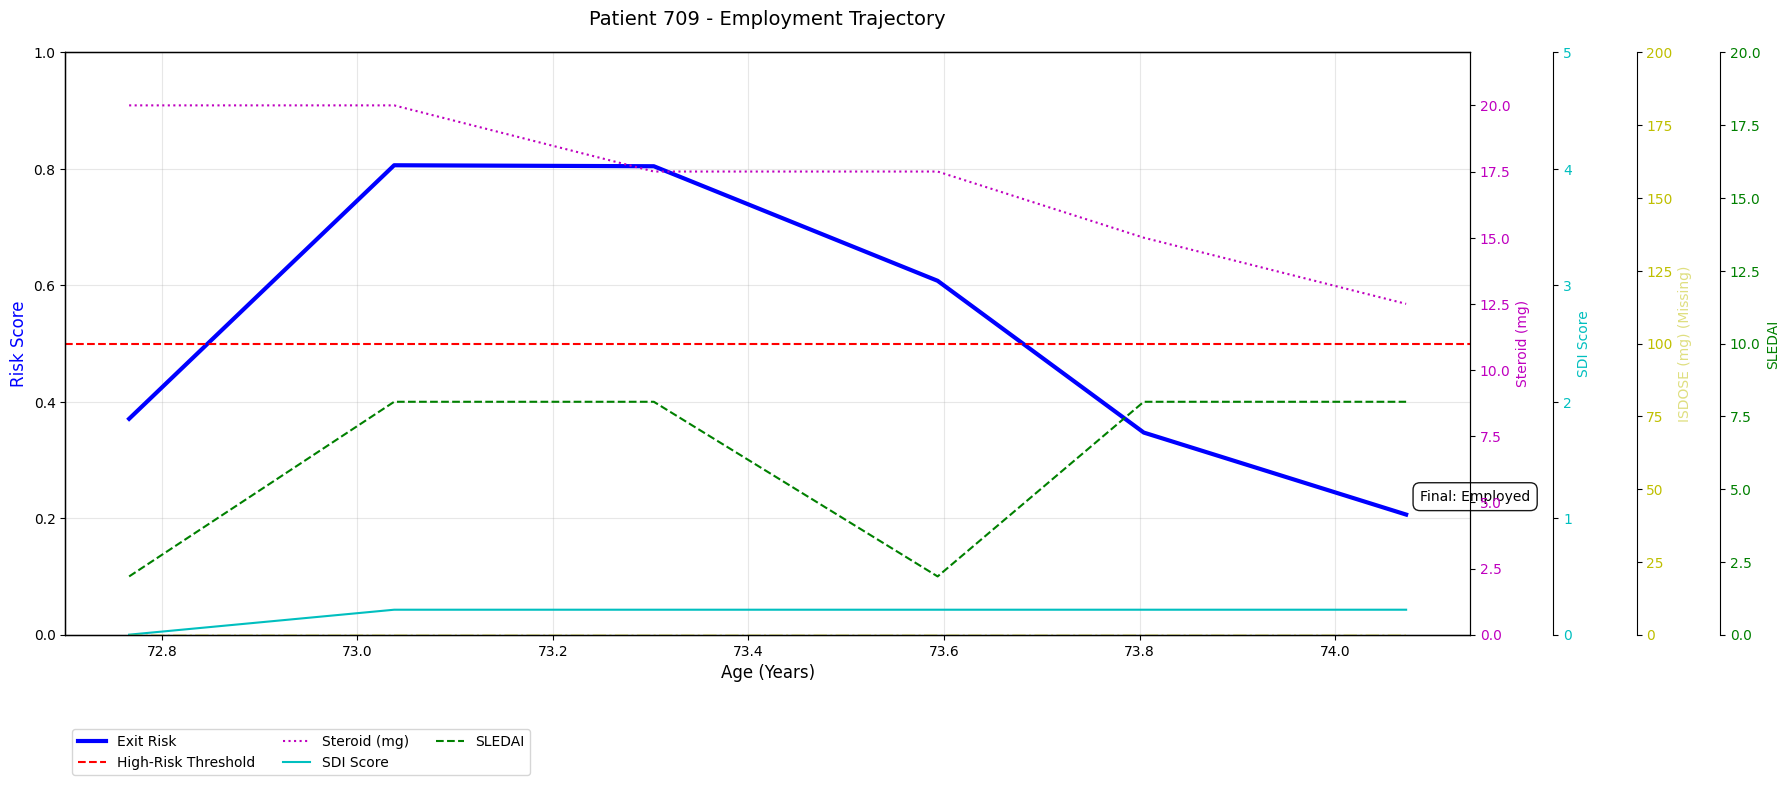

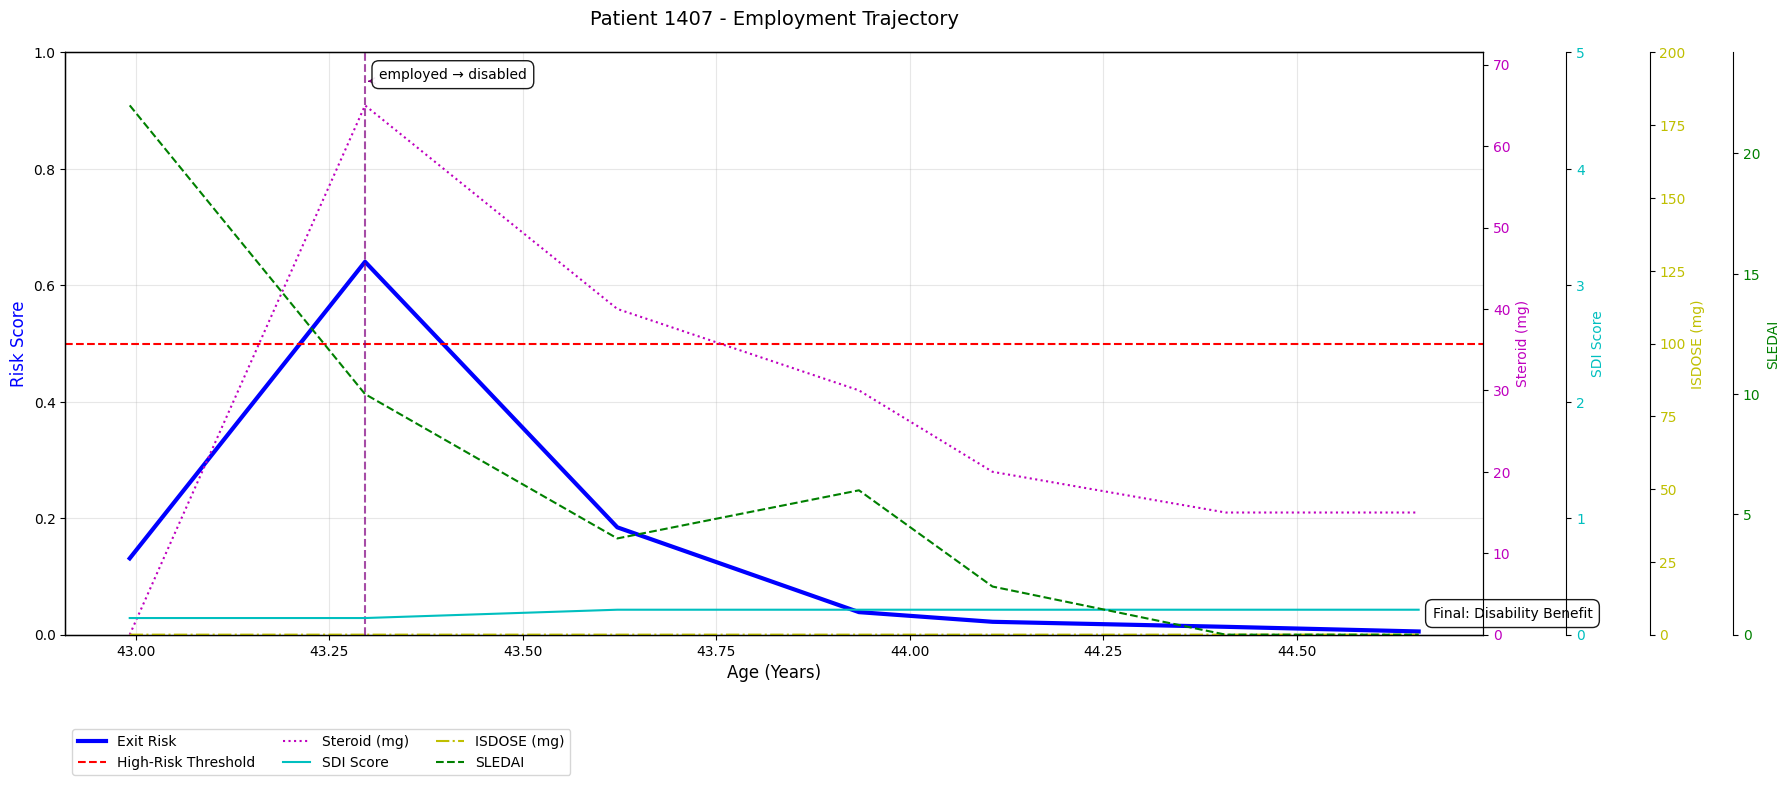

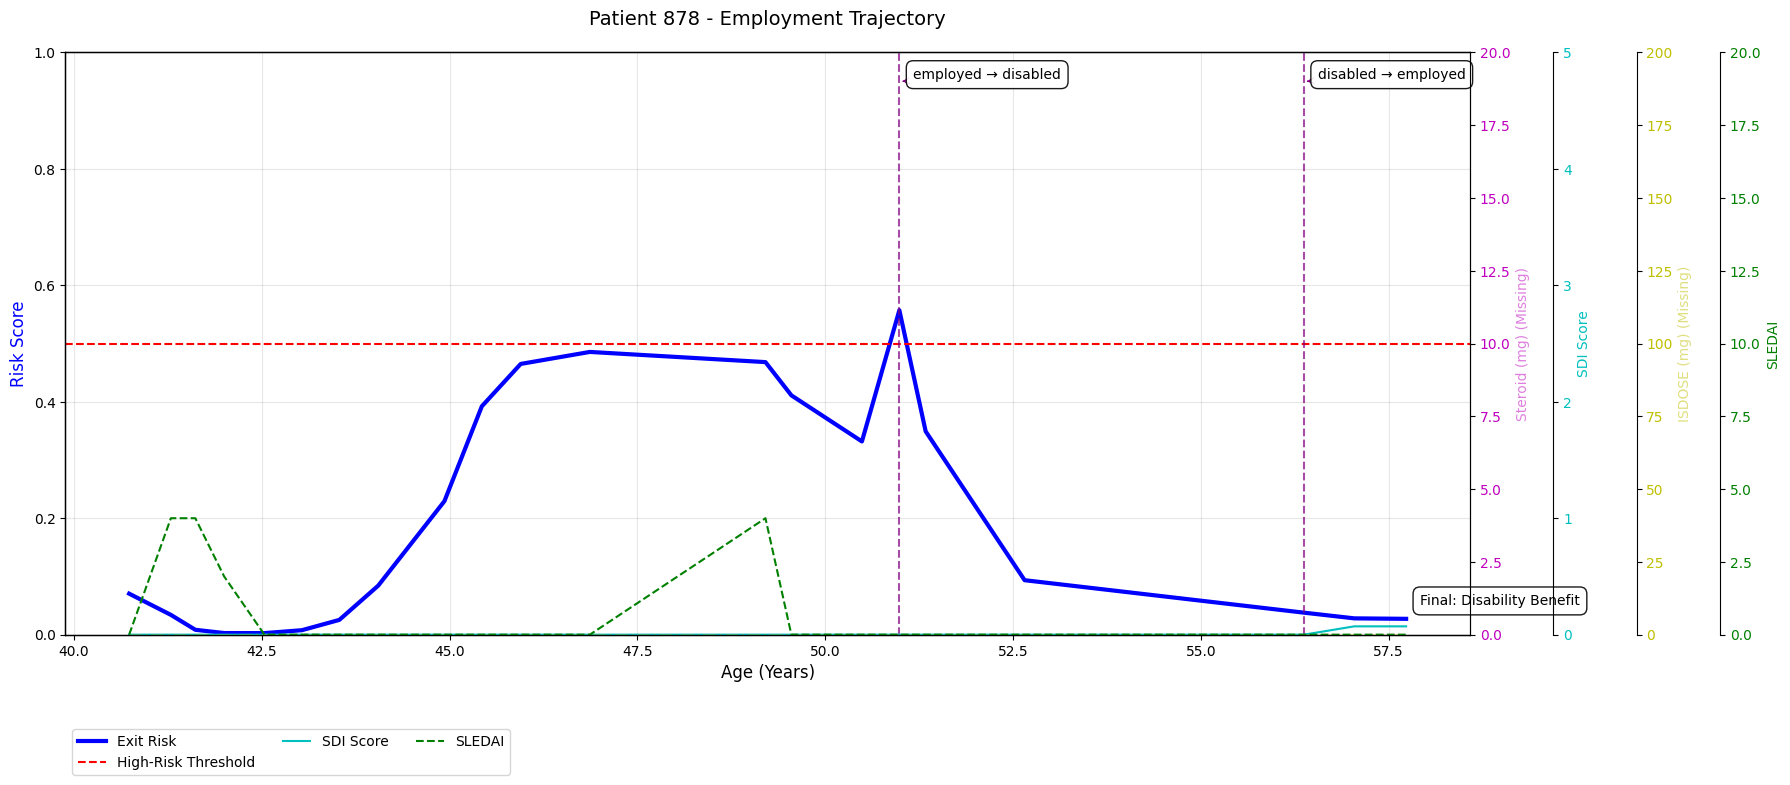

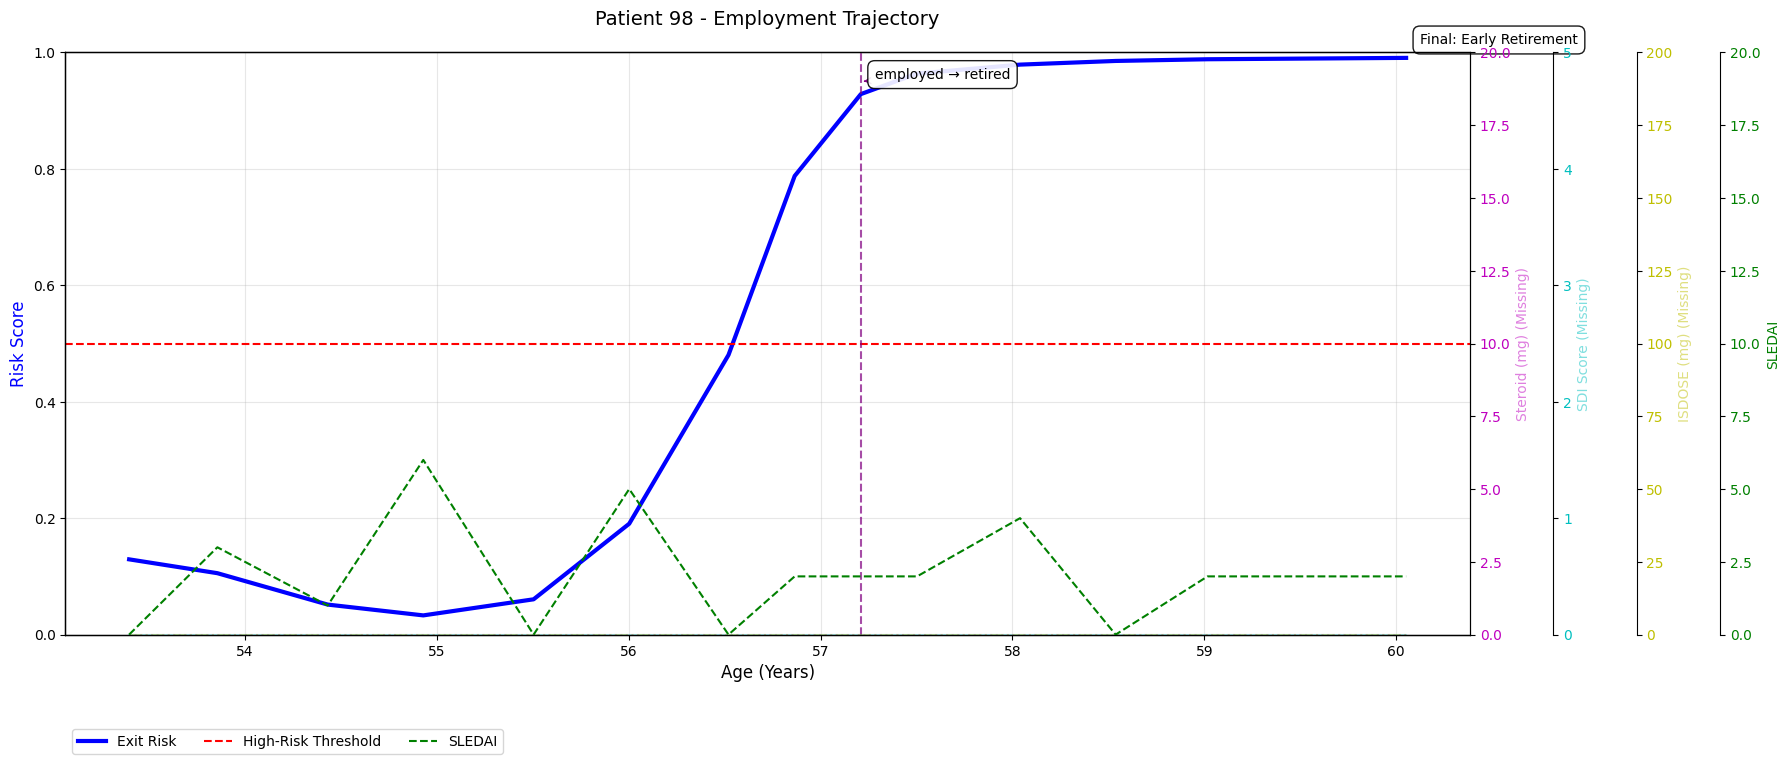

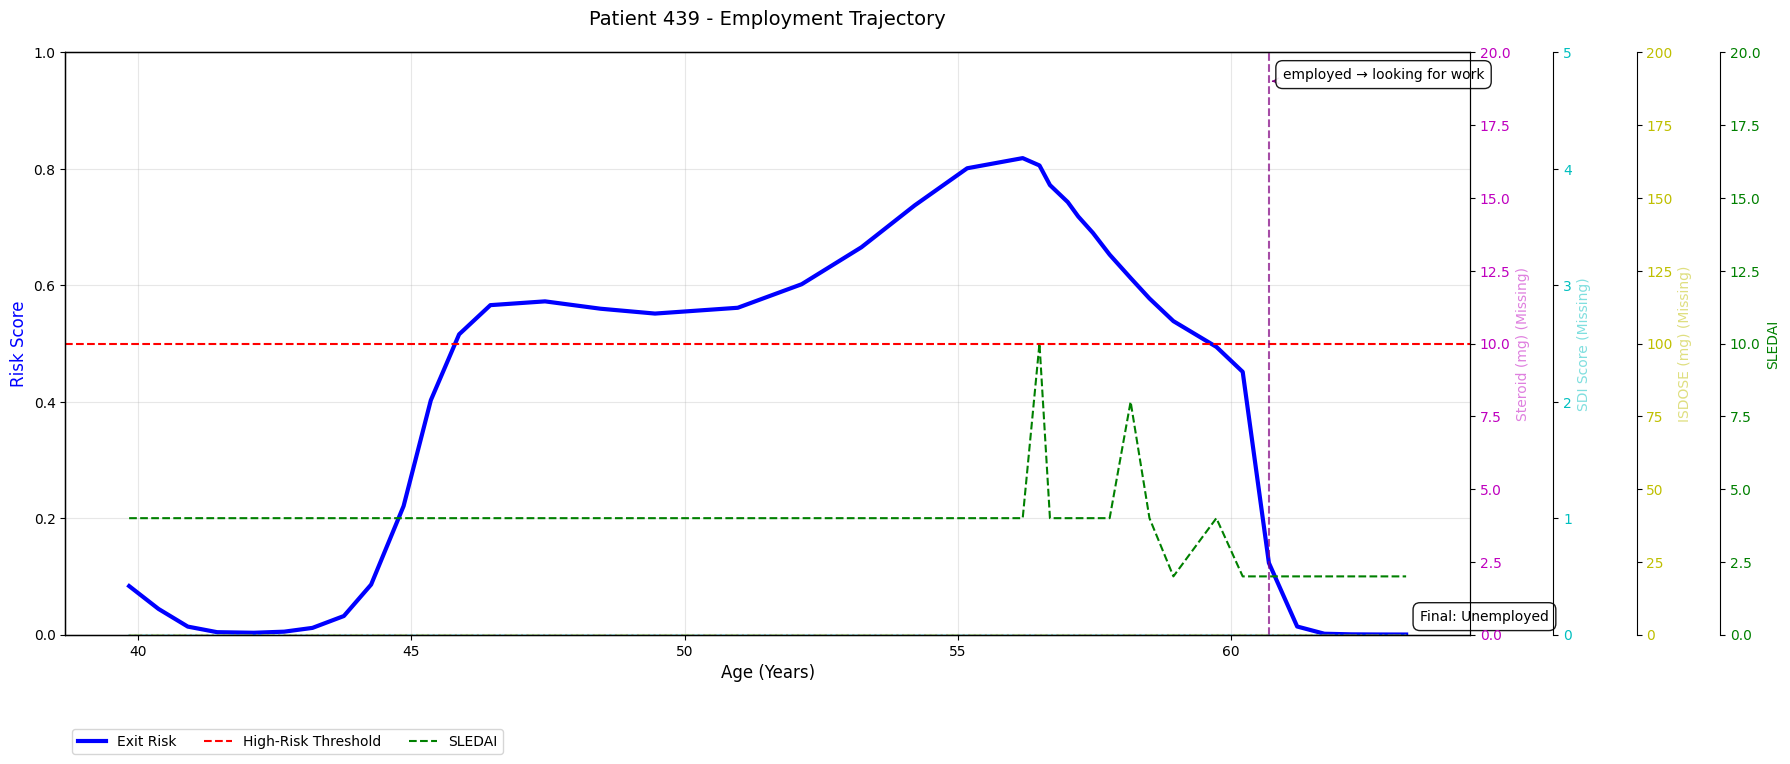

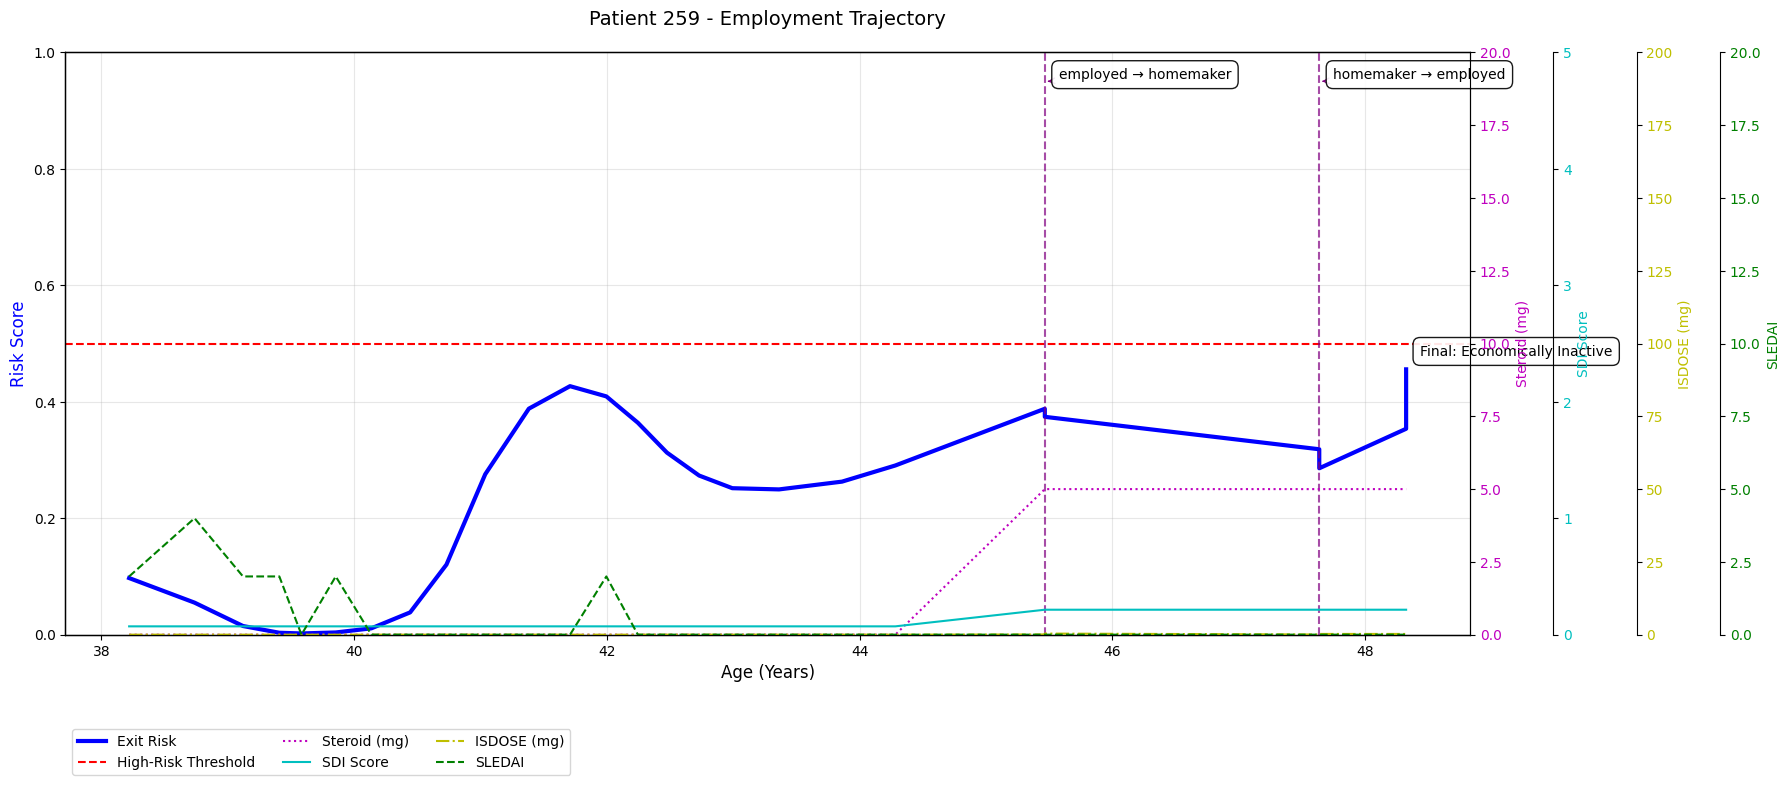

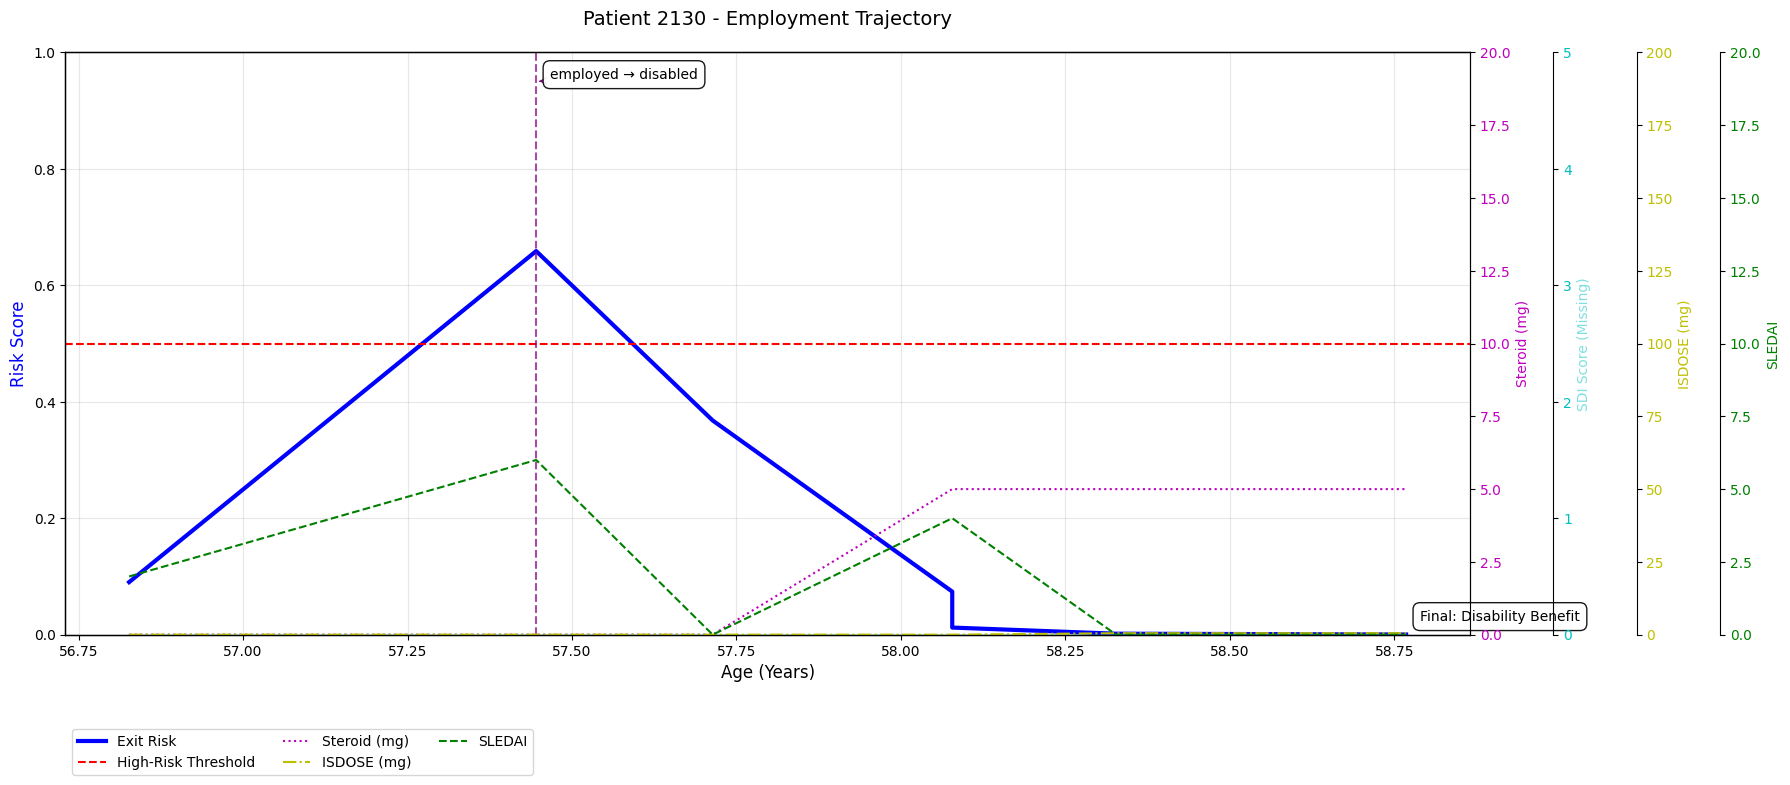

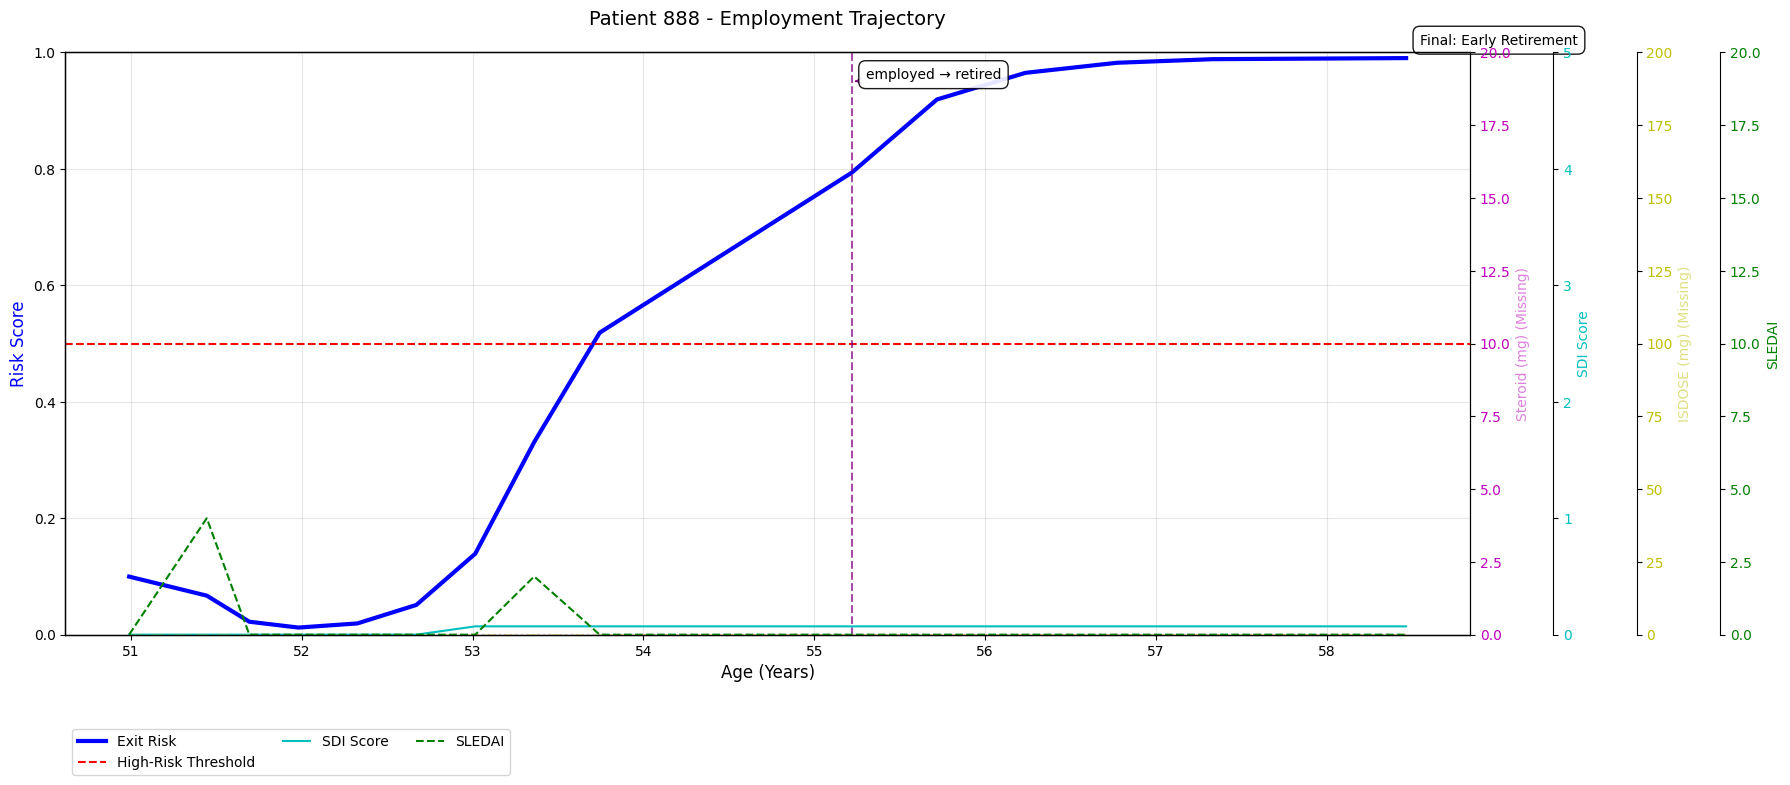

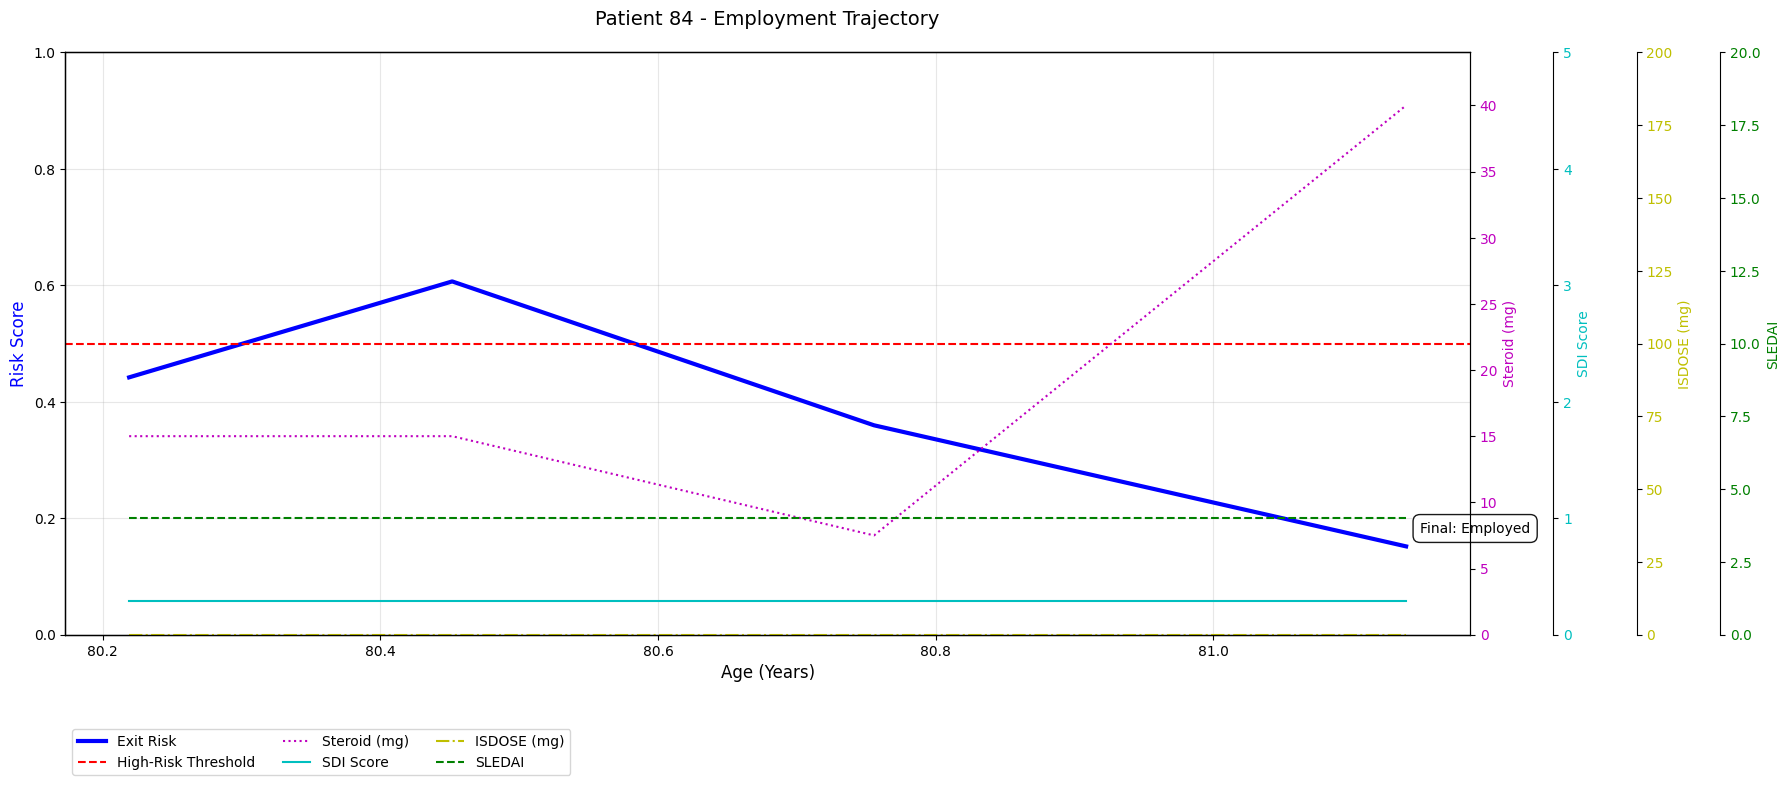

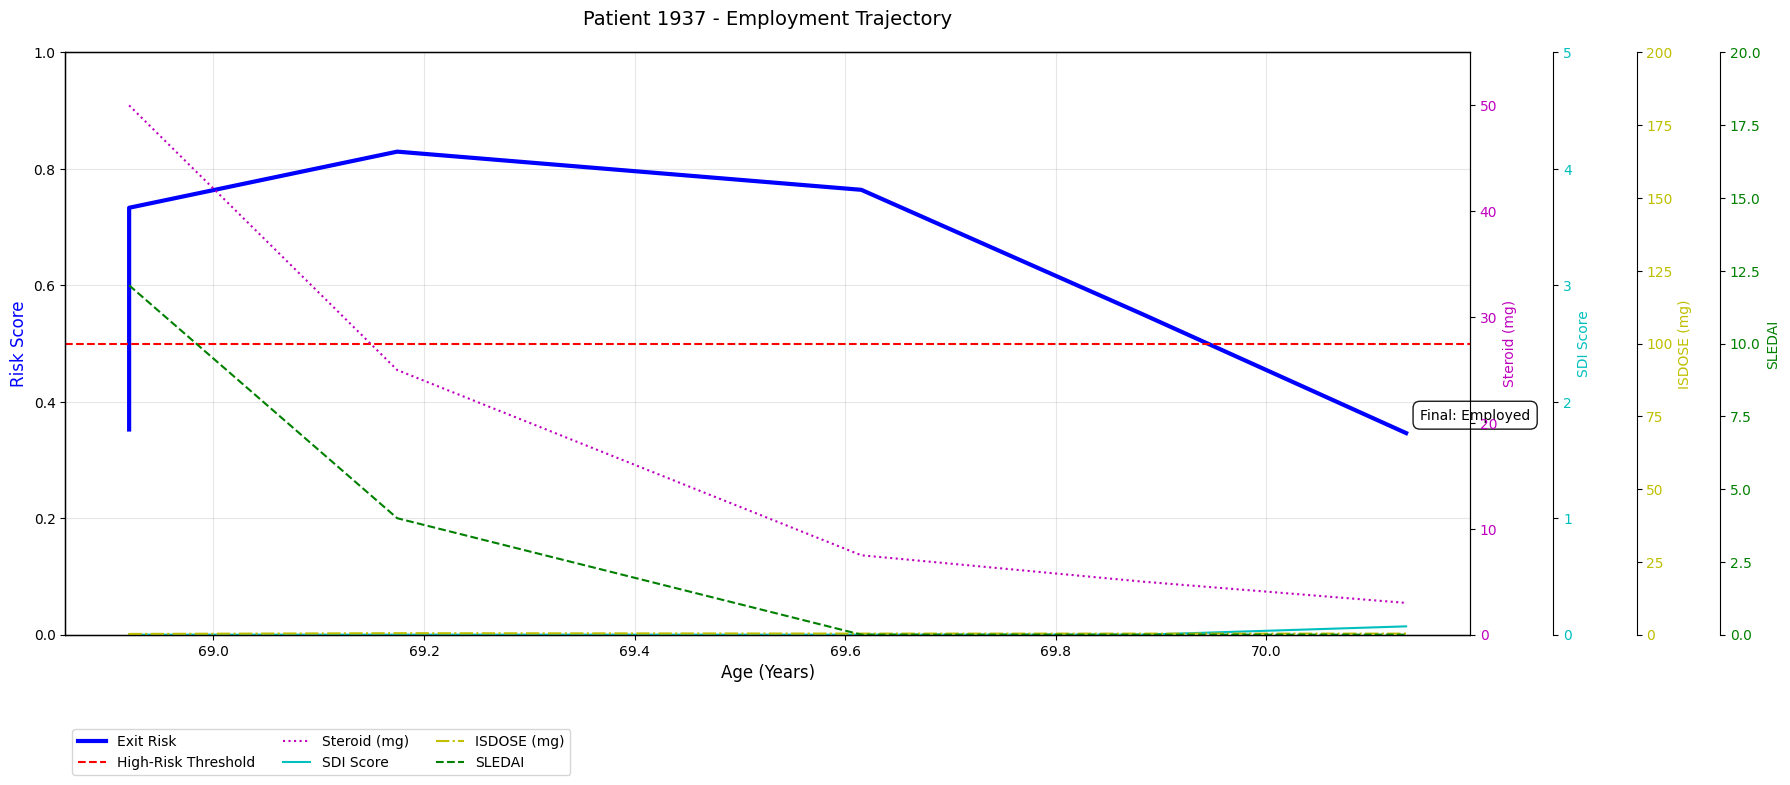

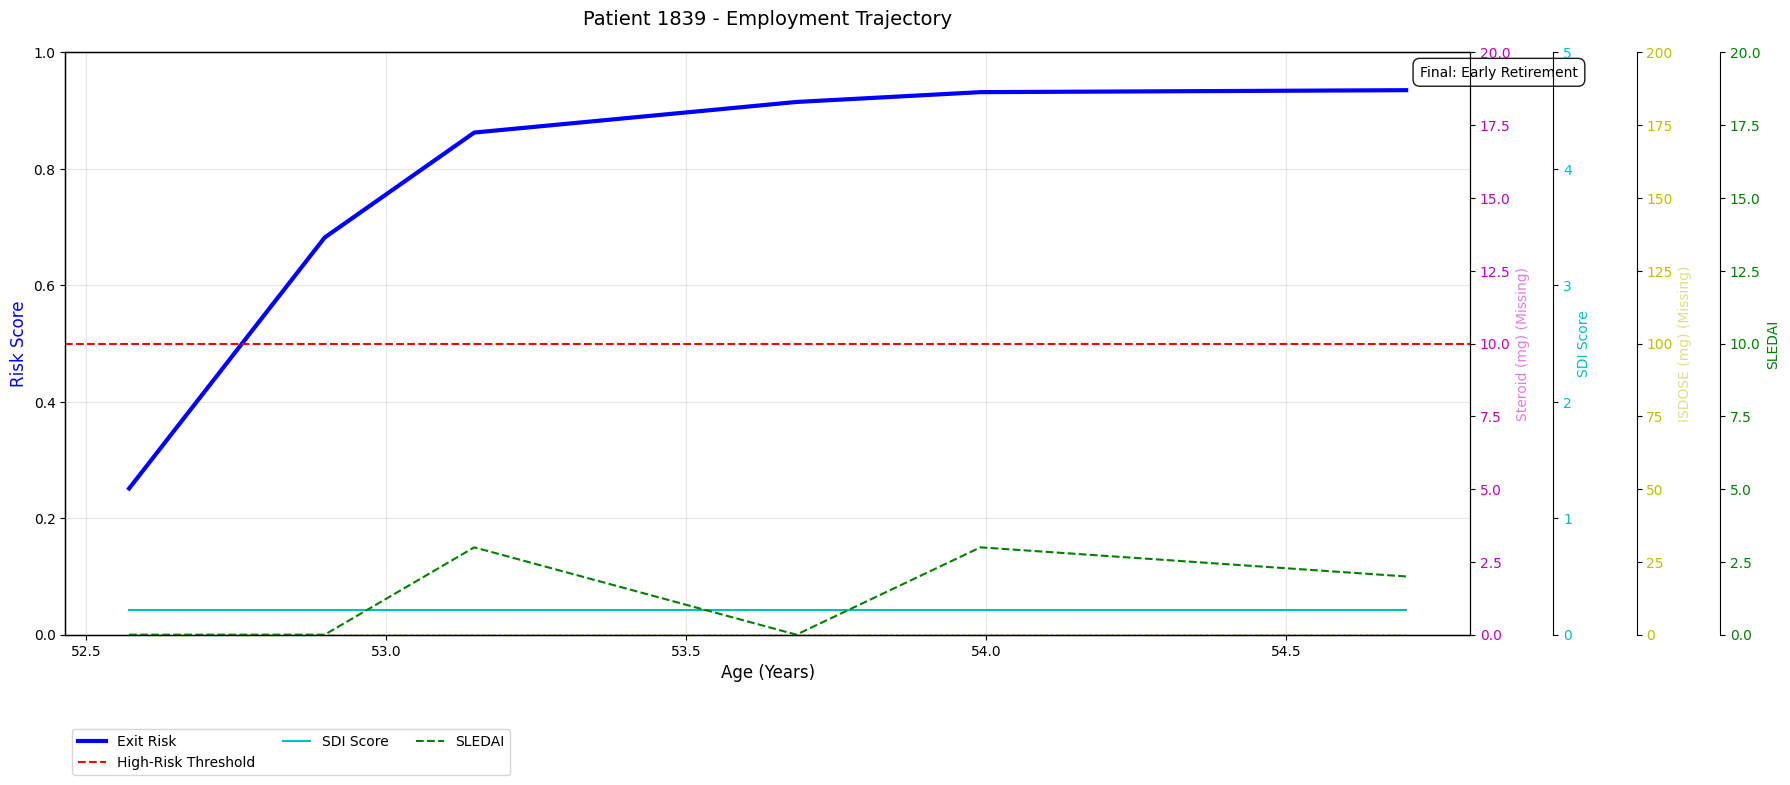

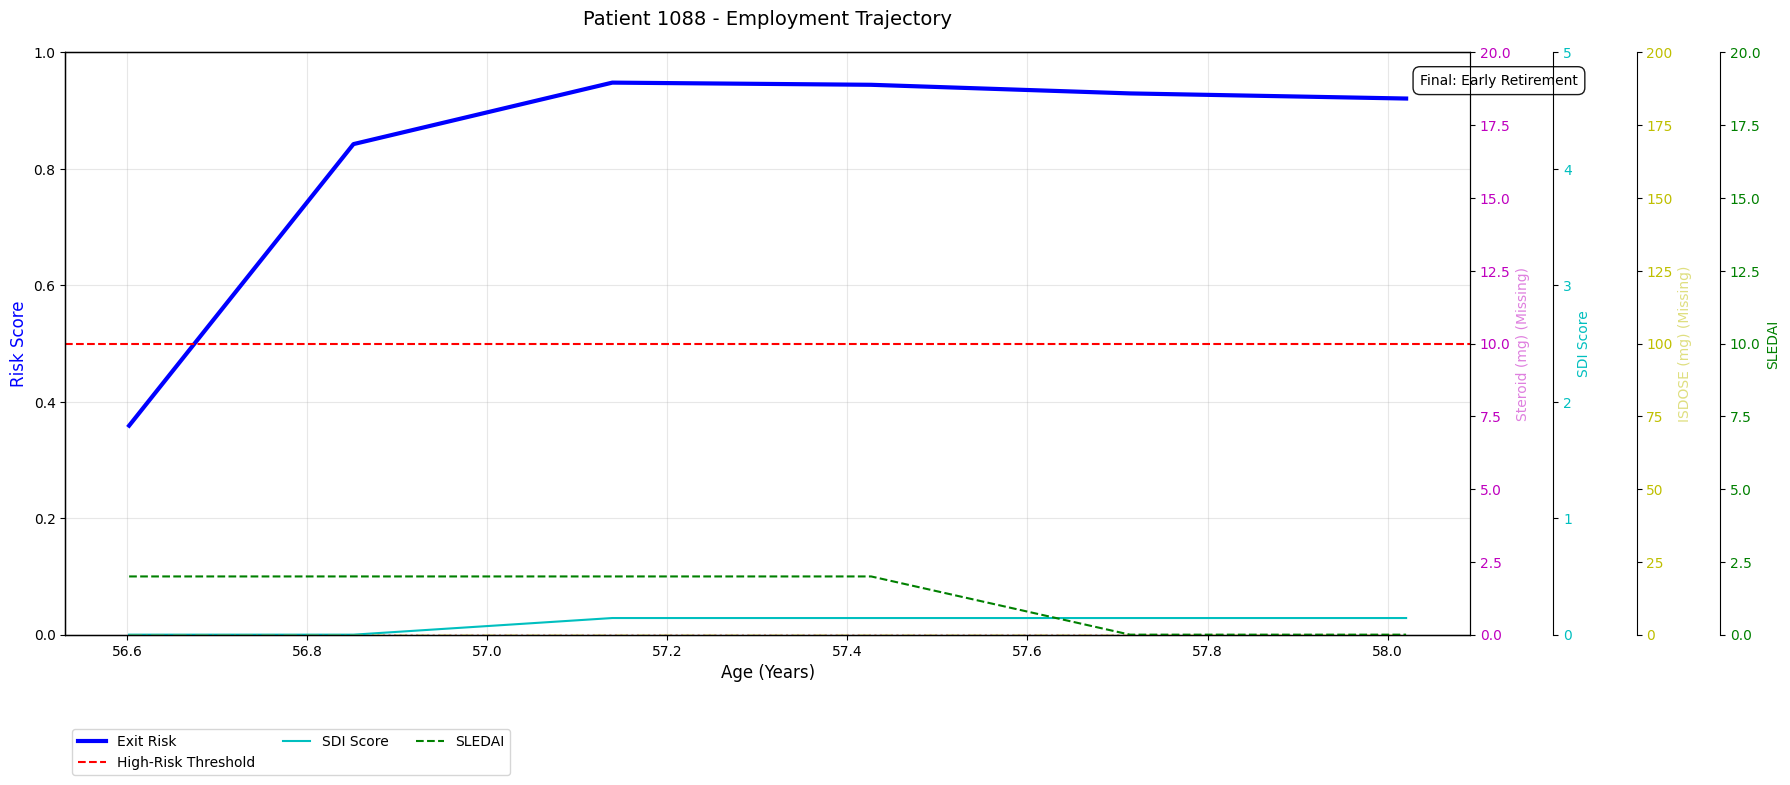

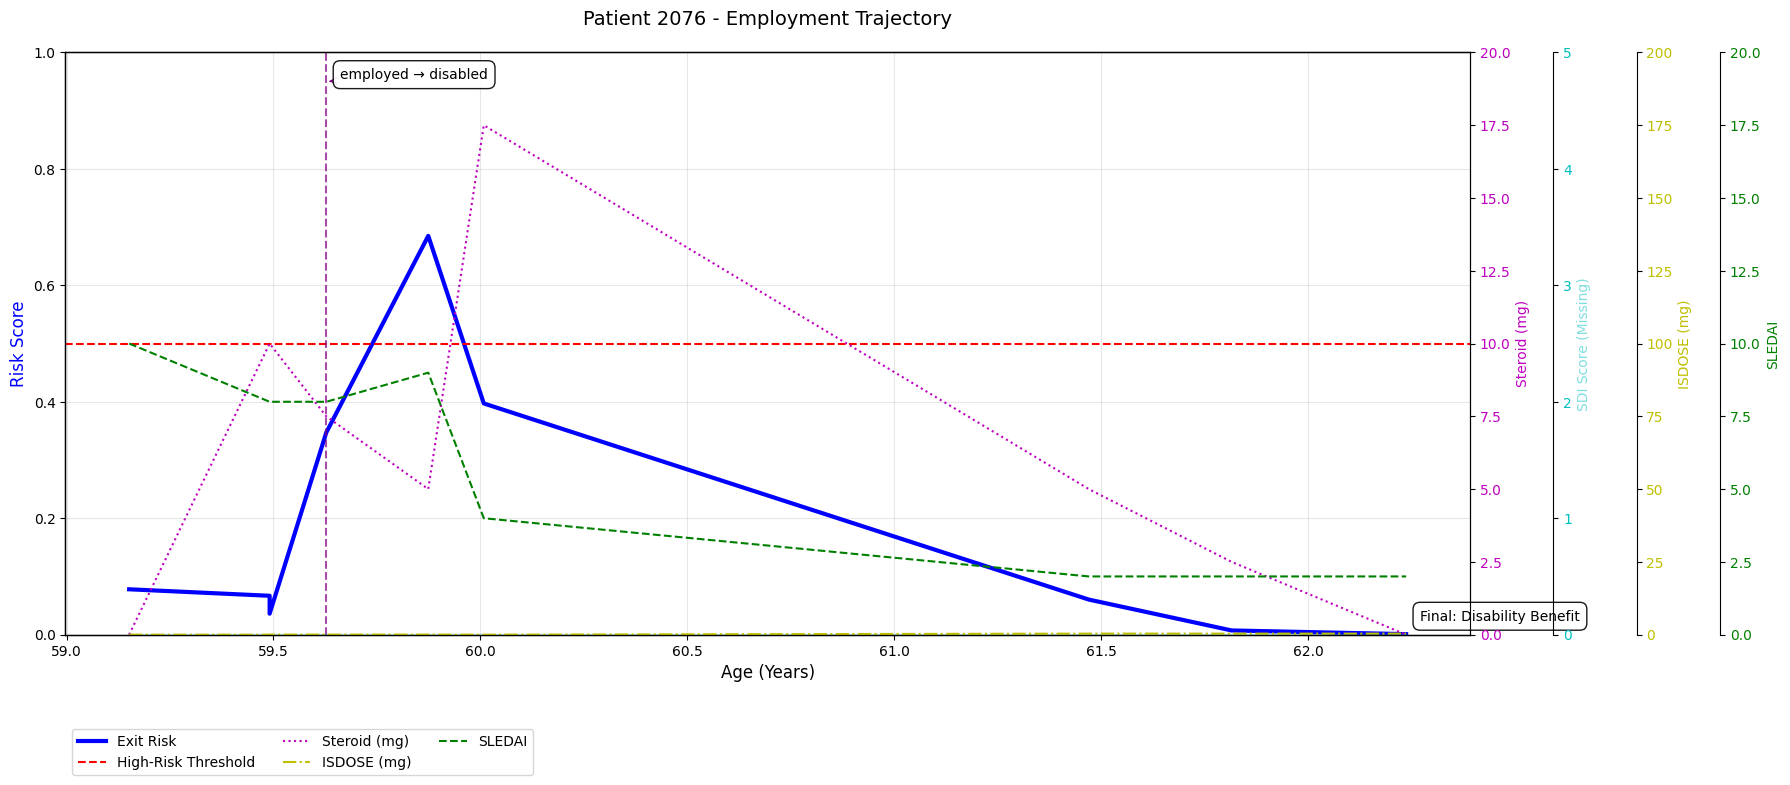

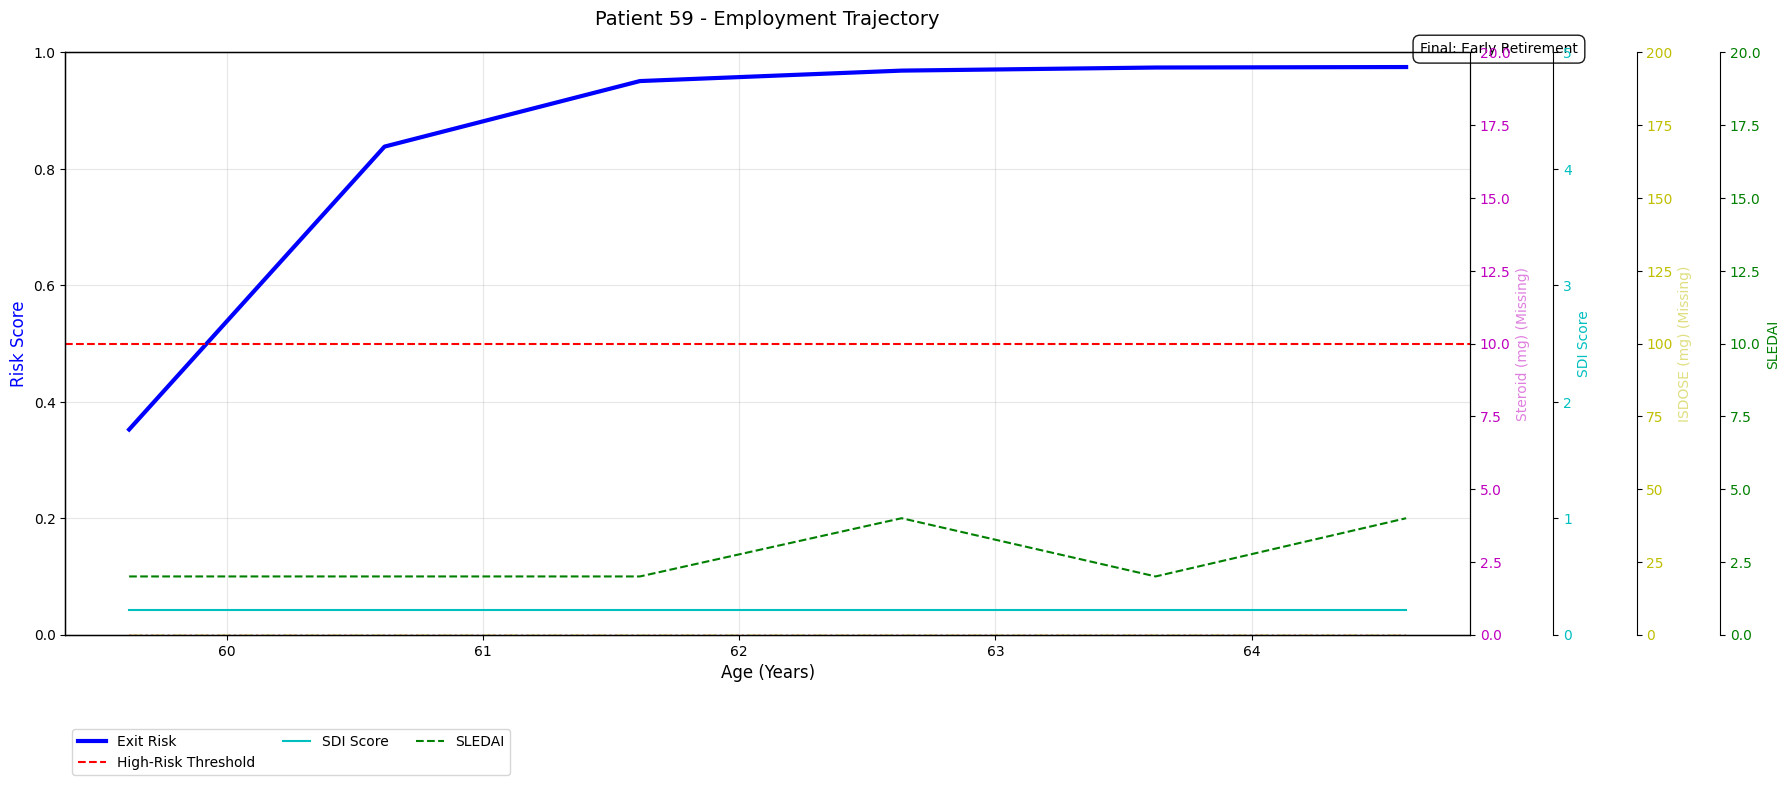

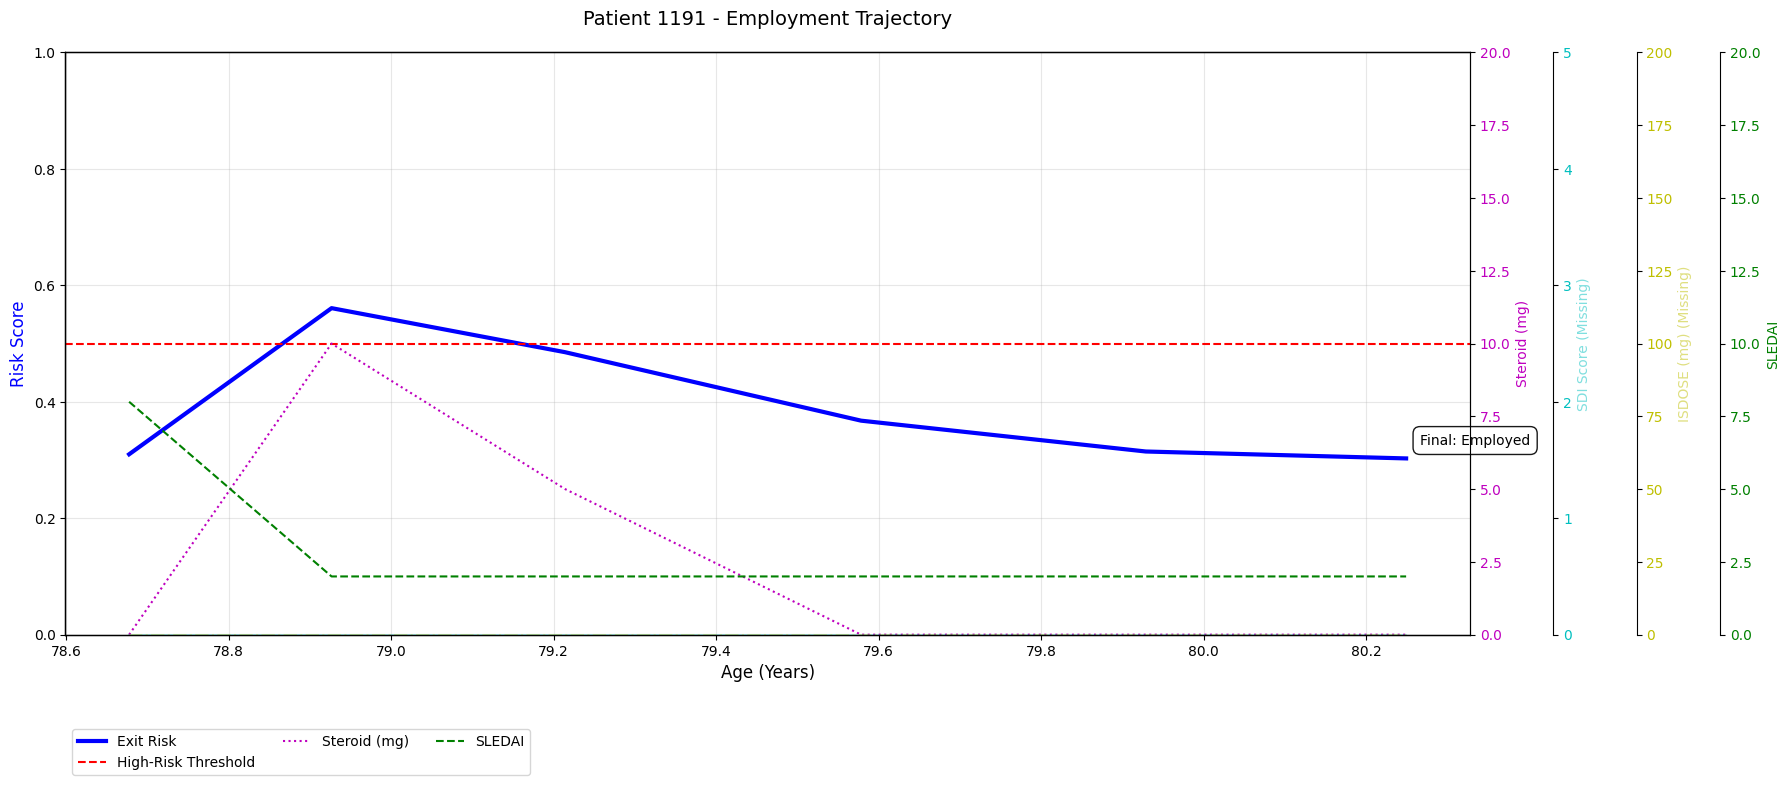

In [111]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Enhanced trajectory plot with clear employment transition markers and guaranteed axis visibility"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age
    if 'BIRTHDT' in patient_data.columns:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    else:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['ASSDT'].min()).dt.days / 365.25
    
    # Get risk predictions
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = patient_data['Age'].values
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(18, 8))
    
    # Plot risk score (always shown)
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Mark high-risk threshold
    threshold = risk_df['Threshold_Used'].iloc[0] if 'Threshold_Used' in risk_df.columns else 0.5
    ax1.axhline(y=threshold, color='r', linestyle='--', label='High-Risk Threshold')
    
    # Standard clinical markers with guaranteed display
    clinical_markers = {
        'Steroid': {
            'values': risk_df['Steroid_Dose'].fillna(0) if 'Steroid_Dose' in risk_df else np.zeros(len(risk_df)),
            'color': 'm',
            'style': ':',
            'label': 'Steroid (mg)',
            'scale': 1,
            'default_max': 20  # Default max steroid dose for scaling
        },
        'SDI': {
            'values': risk_df['SDI'].fillna(0) if 'SDI' in risk_df else np.zeros(len(risk_df)),
            'color': 'c',
            'style': '-',
            'label': 'SDI Score',
            'scale': 1,
            'default_max': 5  # SDI typically ranges 0-5
        },
        'Immunosuppressant': {
            'values': risk_df['Immunosuppressant'].fillna(0) if 'Immunosuppressant' in risk_df else np.zeros(len(risk_df)),
            'color': 'y',
            'style': '-.',
            'label': 'ISDOSE (mg)',
            'scale': 1,
            'default_max': 200  # Typical max ISDOSE
        },
        'SLEDAI': {
            'values': risk_df['SLEDAI'].fillna(0) if 'SLEDAI' in risk_df else np.zeros(len(risk_df)),
            'color': 'g',
            'style': '--',
            'label': 'SLEDAI',
            'scale': 1,
            'default_max': 20  # SLEDAI practical max
        }
    }
    
    # Create right axes for all clinical markers (always shown)
    axes_right = {}
    offset = 60
    
    for i, (marker_name, params) in enumerate(clinical_markers.items()):
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset*i))
        
        # Plot the line (even if all zeros)
        line = ax.plot(risk_df['Age'], params['values'], 
                      color=params['color'], 
                      linestyle=params['style'], 
                      label=params['label'])
        
        ax.set_ylabel(params['label'], color=params['color'])
        ax.tick_params(axis='y', labelcolor=params['color'])
        
        # Set consistent y-limits (0 to default_max)
        ax.set_ylim(0, params['default_max'])
        
        # Highlight if data is all zeros/missing
        if np.all(params['values'] == 0):
            line[0].set_alpha(0.3)  # Make line faint if no real data
            ax.set_ylabel(f"{params['label']} (Missing)", color=params['color'], alpha=0.5)
        else:
            # Auto-scale if we have real data
            clean_vals = params['values'][np.isfinite(params['values'])]
            if len(clean_vals) > 0:
                ymax = max(params['default_max'], np.max(clean_vals) * 1.1)
                ax.set_ylim(0, ymax)
        
        axes_right[marker_name] = ax
    
    # Enhanced employment transition markers
    if 'EMPf' in patient_data.columns:
        for i in range(1, len(patient_data)):
            if patient_data['EMPf'].iloc[i] != patient_data['EMPf'].iloc[i-1]:
                transition_age = patient_data['Age'].iloc[i]
                prev_status = patient_data['EMPf'].iloc[i-1]
                new_status = patient_data['EMPf'].iloc[i]
                
                # Add vertical line
                ax1.axvline(x=transition_age, color='purple', linestyle='--', alpha=0.7, linewidth=1.5)
                
                # Add label with arrow
                ax1.annotate(
                    f"{prev_status} → {new_status}",
                    xy=(transition_age, 0.95),
                    xytext=(10, 10),
                    textcoords='offset points',
                    ha='left',
                    va='top',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='purple')
                )
    
    # Highlight first high-risk flag if available
    if 'First_High_Risk_Date' in patient_data.columns and pd.notna(patient_data['First_High_Risk_Date'].iloc[0]):
        flag_age = (patient_data['First_High_Risk_Date'].iloc[0] - patient_data['BIRTHDT'].iloc[0]).days/365.25
        ax1.axvline(x=flag_age, color='darkgreen', linestyle=':', linewidth=2)
        ax1.text(flag_age, 0.9, 'First Risk Flag', rotation=90, 
                ha='right', va='top', color='darkgreen')
    
    # Final outcome annotation
    if 'end_state' in patient_data.columns:
        final_age = patient_data['Age'].iloc[-1]
        ax1.annotate(
            f"Final: {patient_data['end_state'].iloc[-1]}",
            xy=(final_age, risk_df['Risk_Score'].iloc[-1]),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9)
        )
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for marker_name, ax in axes_right.items():
        lines, labels = ax.get_legend_handles_labels()
        # Only include in legend if we have real data
        if not np.all(clinical_markers[marker_name]['values'] == 0):
            lines_right.extend(lines)
            labels_right.extend(labels)
    
    if lines_right:  # Only add if we have right axis data
        ax1.legend(lines1 + lines_right, labels1 + labels_right, 
                  loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3)
    else:
        ax1.legend(lines1, labels1, loc='upper left', bbox_to_anchor=(0, -0.15))
    
    plt.title(f'Patient {pid} - Employment Trajectory', fontsize=14, pad=20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

# Convert date columns to datetime if they're strings
date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date', 'Final_Outcome_Date']
for col in date_cols:
    if col in data.columns and data[col].dtype == object:
        data[col] = pd.to_datetime(data[col], errors='coerce')
    if col in high_risk_df.columns and high_risk_df[col].dtype == object:
        high_risk_df[col] = pd.to_datetime(high_risk_df[col], errors='coerce')
        
# Visualize example cases with age on x-axis
if not high_risk_df.empty:
    print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
    for pid in high_risk_df['PTNO'].sample(min(20, len(high_risk_df)), random_state=365):
        plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)
else:
    print("No high-risk patients to visualize.")